# Recruit Restaurant Visitor Forecasting - EDA 분석

1. 파일 구조와 데이터 특징 확인
2. 방문자 수의 시간/요일/월별 패턴 확인
3. 예약 데이터와 실제 방문자 수의 관계 확인
4. 장르, 지역, 공휴일 효과 확인
5. 예측 성능 향상을 위한 Feature 가정 정리

## 0. 라이브러리와 데이터 로딩

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import matplotlib.dates as mdates
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)


plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

AIR_COLOR = "blue"
HPG_COLOR = "red"
ORANGE = "orange"
BLACK = "black"
GREY = "grey"
AIR_COLOR = "blue"
HPG_COLOR = "red"

In [36]:
df_ar = pd.read_csv('data/air_reserve.csv')
df_asi = pd.read_csv('data/air_store_info.csv')
df_avd = pd.read_csv('data/air_visit_data.csv')
df_di = pd.read_csv('data/date_info.csv')
df_hr = pd.read_csv('data/hpg_reserve.csv')
df_hsi = pd.read_csv('data/hpg_store_info.csv')
df_si = pd.read_csv('data/store_id_relation.csv')
df_ss = pd.read_csv("data/sample_submission.csv")

## 1. 파일 구조와 기본 특징

하나의 테이블이 아니라 여러 CSV를 결합하는 **관계형 데이터 분석 문제**

In [37]:
dataframes = {
    "air_reserve": df_ar,
    "air_store_info": df_asi,
    "air_visit_data": df_avd,
    "date_info": df_di,
    "hpg_reserve": df_hr,
    "hpg_store_info": df_hsi,
    "store_id_relation": df_si,
    "sample_submission": df_ss
}

summary = []
for name, df in dataframes.items():
    summary.append({
        "file_name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicated_rows": df.duplicated().sum(),
        "missing_values": df.isna().sum().sum()
    })

file_summary = pd.DataFrame(summary)
display(file_summary)

for name, df in dataframes.items():
    print("" + "=" * 80)
    print(name, df.shape)
    display(df.head(3))

,file_name,rows,columns,duplicated_rows,missing_values
0,air_reserve,92378,4,2770,0
1,air_store_info,829,5,0,0
2,air_visit_data,252108,3,0,0
3,date_info,517,3,0,0
4,hpg_reserve,1048575,4,6971,0
5,hpg_store_info,4690,5,0,0
6,store_id_relation,150,2,0,0
7,sample_submission,32019,2,0,0


air_reserve (92378, 4)


,air_store_id,visit_datetime,reserve_datetime,reserve_visitors
0,air_877f79706adbfb06,2016-01-01 19:00,2016-01-01 16:00,1
1,air_db4b38ebe7a7ceff,2016-01-01 19:00,2016-01-01 19:00,3
2,air_db4b38ebe7a7ceff,2016-01-01 19:00,2016-01-01 19:00,6


air_store_info (829, 5)


,air_store_id,air_genre_name,air_area_name,latitude,longitude
0,air_0f0cdeee6c9bf3d7,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
1,air_7cc17a324ae5c7dc,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
2,air_fee8dcf4d619598e,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853


...

,hpg_store_id,hpg_genre_name,hpg_area_name,latitude,longitude
0,hpg_6622b62385aec8bf,Japanese style,Tōkyō-to Setagaya-ku Taishidō,35.643675,139.668221
1,hpg_e9e068dd49c5fa00,Japanese style,Tōkyō-to Setagaya-ku Taishidō,35.643675,139.668221
2,hpg_2976f7acb4b3a3bc,Japanese style,Tōkyō-to Setagaya-ku Taishidō,35.643675,139.668221


store_id_relation (150, 2)


,air_store_id,hpg_store_id
0,air_63b13c56b7201bd9,hpg_4bc649e72e2a239a
1,air_a24bf50c3e90d583,hpg_c34b496d0305a809
2,air_c7f78b4f3cba33ff,hpg_cd8ae0d9bbd58ff9


sample_submission (32019, 2)


,id,visitors
0,air_00a91d42b08b08d9_2017-04-23,0
1,air_00a91d42b08b08d9_2017-04-24,0
2,air_00a91d42b08b08d9_2017-04-25,0


**해석**

- `air_visit_data.csv`가 학습용 정답 데이터입니다. 즉, `air_store_id`, `visit_date`, `visitors`가 핵심입니다.
- `sample_submission.csv`는 예측해야 하는 `air_store_id + visit_date` 조합입니다.
- `air_reserve`, `hpg_reserve`는 예약 로그이므로, 모델링 시 식당-방문일 단위로 집계해야 합니다.
- `store_id_relation`은 hpg 식당 ID를 air 식당 ID로 연결할 때 필요합니다.

## 2. 날짜 변환과 기본 Feature 생성

시계열 분석과 EDA를 위해 날짜 컬럼을 `datetime`으로 바꾸고, 요일/월/주말 여부를 만듭니다.

In [38]:
# 날짜 타입 변환
df_avd["visit_date"] = pd.to_datetime(df_avd["visit_date"])
df_di["calendar_date"] = pd.to_datetime(df_di["calendar_date"])
df_ar["visit_datetime"] = pd.to_datetime(df_ar["visit_datetime"])
df_ar["reserve_datetime"] = pd.to_datetime(df_ar["reserve_datetime"])
df_hr["visit_datetime"] = pd.to_datetime(df_hr["visit_datetime"])
df_hr["reserve_datetime"] = pd.to_datetime(df_hr["reserve_datetime"])

# sample_submission에서 air_store_id와 visit_date 분리
df_ss[["air_store_id", "visit_date"]] = df_ss["id"].str.rsplit("_", n=1, expand=True)
df_ss["visit_date"] = pd.to_datetime(df_ss["visit_date"])

# 방문 데이터 기본 날짜 Feature
df_avd["year"] = df_avd["visit_date"].dt.year
df_avd["month"] = df_avd["visit_date"].dt.month
df_avd["day"] = df_avd["visit_date"].dt.day
df_avd["dayofweek"] = df_avd["visit_date"].dt.dayofweek  # 월=0, 일=6
df_avd["is_weekend"] = df_avd["dayofweek"].isin([5, 6]).astype(int)
df_avd["log_visitors"] = np.log1p(df_avd["visitors"])

dow_map = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}
dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_order_r = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

df_avd["dow_name"] = df_avd["dayofweek"].map(dow_map)
df_avd["dow_name"] = pd.Categorical(df_avd["dow_name"], categories=dow_order, ordered=True)

display(df_avd.head())

,air_store_id,visit_date,visitors,year,month,day,dayofweek,is_weekend,log_visitors,dow_name
0,air_ba937bf13d40fb24,2016-01-13,25,2016,1,13,2,0,3.258097,Wed
1,air_ba937bf13d40fb24,2016-01-14,32,2016,1,14,3,0,3.496508,Thu
2,air_ba937bf13d40fb24,2016-01-15,29,2016,1,15,4,0,3.401197,Fri
3,air_ba937bf13d40fb24,2016-01-16,22,2016,1,16,5,1,3.135494,Sat
4,air_ba937bf13d40fb24,2016-01-18,6,2016,1,18,0,0,1.945910,Mon


## 3. Air visits: 전체 방문자, 분포, 요일, 월별 패턴

원본 Rmd의 Fig.1에 해당하는 핵심 시각화입니다.  
Box plot 대신 원본처럼 **선그래프 + 히스토그램 + 중앙값 막대그래프**로 구성합니다.

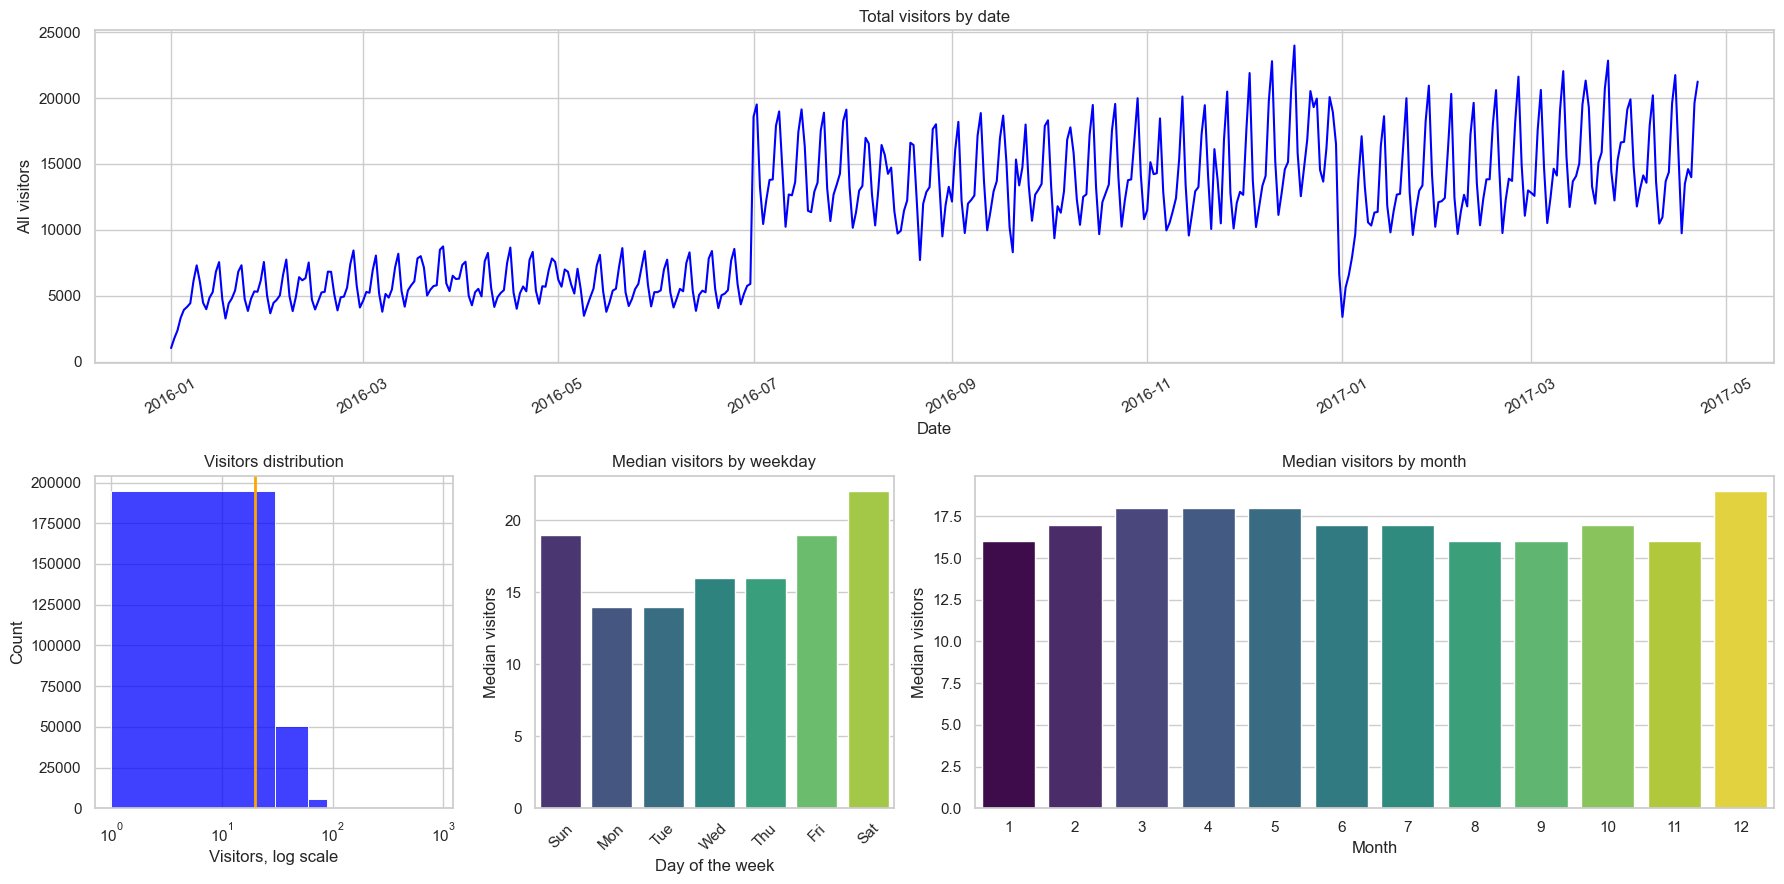

,count,mean,median,std,min,max
dow_name,,,,,,
Mon,31682,17.177009,14.0,14.105566,1,348
Tue,36015,17.672137,14.0,14.611202,1,777
Wed,36811,19.230121,16.0,15.378986,1,877
Thu,37996,18.922702,16.0,14.606176,1,369
Fri,40351,23.072737,19.0,16.575974,1,325
Sat,39262,26.313688,22.0,18.934794,1,409
Sun,29991,23.873362,19.0,20.131047,1,675


In [39]:
daily_visitors = (
    df_avd.groupby("visit_date", as_index=False)["visitors"]
    .sum()
    .rename(columns={"visitors": "all_visitors"})
)

dow_median = (
    df_avd.groupby("dow_name", observed=False)["visitors"]
    .median()
    .reindex(dow_order_r)
    .reset_index()
    .rename(columns={"visitors": "median_visitors"})
)

month_median = (
    df_avd.groupby("month")["visitors"]
    .median()
    .reset_index()
    .rename(columns={"visitors": "median_visitors"})
)

fig = plt.figure(figsize=(18, 9))
gs = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(gs[0, :4])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2:])

# p1: 일별 전체 방문자 수
sns.lineplot(data=daily_visitors, x="visit_date", y="all_visitors", color=AIR_COLOR, ax=ax1)
ax1.set_title("Total visitors by date")
ax1.set_xlabel("Date")
ax1.set_ylabel("All visitors")
ax1.tick_params(axis="x", rotation=30)

# p2: visitors 분포, x축 log scale, 20명 기준선
sns.histplot(df_avd["visitors"], bins=30, color=AIR_COLOR, ax=ax2)
ax2.axvline(20, color=ORANGE, linewidth=2)
ax2.set_xscale("log")
ax2.set_title("Visitors distribution")
ax2.set_xlabel("Visitors, log scale")

# p3: 요일별 방문자 중앙값
sns.barplot(data=dow_median, x="dow_name", y="median_visitors", hue="dow_name", palette="viridis", legend=False, ax=ax3)
ax3.set_title("Median visitors by weekday")
ax3.set_xlabel("Day of the week")
ax3.set_ylabel("Median visitors")
ax3.tick_params(axis="x", rotation=45)

# p4: 월별 방문자 중앙값
sns.barplot(data=month_median, x="month", y="median_visitors", hue="month", palette="viridis", legend=False, ax=ax4)
ax4.set_title("Median visitors by month")
ax4.set_xlabel("Month")
ax4.set_ylabel("Median visitors")

plt.tight_layout()
plt.show()

# 요일별 통계 테이블은 유지
dow_stats = (
    df_avd
    .groupby("dow_name", observed=False)["visitors"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .loc[dow_order]
)
display(dow_stats)

**해석**

- 전체 방문자 수는 장기적으로 증가하는 구간이 보입니다. 이는 신규 식당이 데이터에 추가된 영향일 수 있습니다.
- 방문자 수 분포는 오른쪽 꼬리가 긴 형태입니다. 따라서 모델링에서는 `log1p(visitors)` 변환이 유리합니다.
- 요일별 중앙값은 금요일과 주말이 높고, 월요일과 화요일이 낮은 경향이 있습니다.
- 월별로는 12월이 높고, 3~5월도 비교적 바쁜 구간으로 볼 수 있습니다.

**예측 가정**  
`air_store_id × dayofweek`별 과거 평균/중앙값은 강력한 baseline Feature가 될 가능성이 높습니다.

## 4. 2016년 Golden Week 구간 확인

테스트셋은 2017년 4월 말~5월이며, 일본 Golden Week가 포함됩니다.  

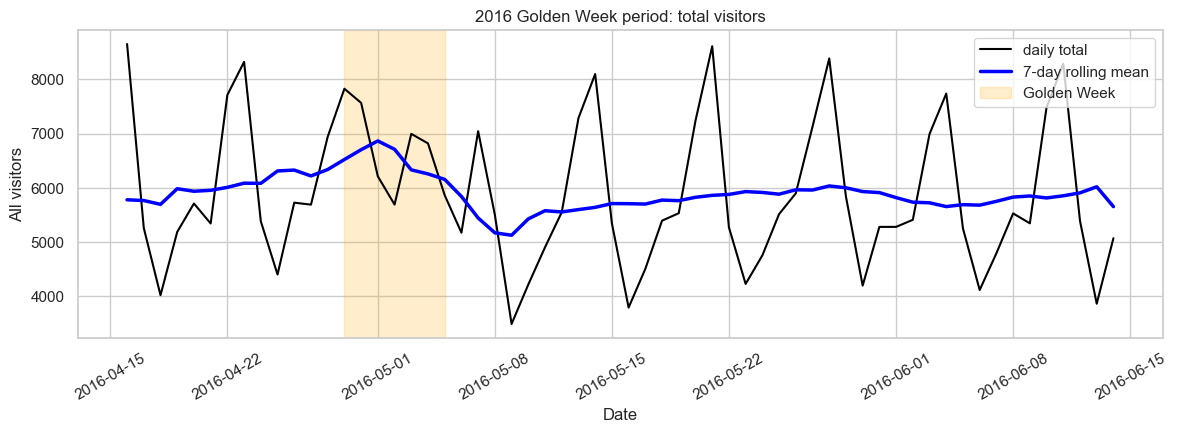

In [40]:
gw_2016 = daily_visitors[
    (daily_visitors["visit_date"] > "2016-04-15") &
    (daily_visitors["visit_date"] < "2016-06-15")
].copy()

gw_2016["rolling_7"] = gw_2016["all_visitors"].rolling(7, center=True, min_periods=1).mean()

plt.figure(figsize=(14, 4))
sns.lineplot(data=gw_2016, x="visit_date", y="all_visitors", color=BLACK, label="daily total")
sns.lineplot(data=gw_2016, x="visit_date", y="rolling_7", color=AIR_COLOR, linewidth=2.5, label="7-day rolling mean")

plt.axvspan(pd.Timestamp("2016-04-29"), pd.Timestamp("2016-05-05"), color=ORANGE, alpha=0.2, label="Golden Week")
plt.title("2016 Golden Week period: total visitors")
plt.xlabel("Date")
plt.ylabel("All visitors")
plt.xticks(rotation=30)
plt.legend()
plt.show()

**해석**

- 2016년 4월 29일~5월 5일 구간에서 평소와 다른 패턴이 나타납니다.
- 테스트 기간이 2017년 Golden Week를 포함하므로, 일반적인 요일 효과만으로는 부족합니다.

**예측 가정**  
`is_golden_week`, `before_holiday`, `after_holiday` 같은 휴일 주변 Feature를 추가해야 합니다.

## 5. Air / HPG 예약 데이터 패턴

예약 방문일 추이, 방문 시간대, 예약 후 방문까지의 시간 차이를 봅니다.  

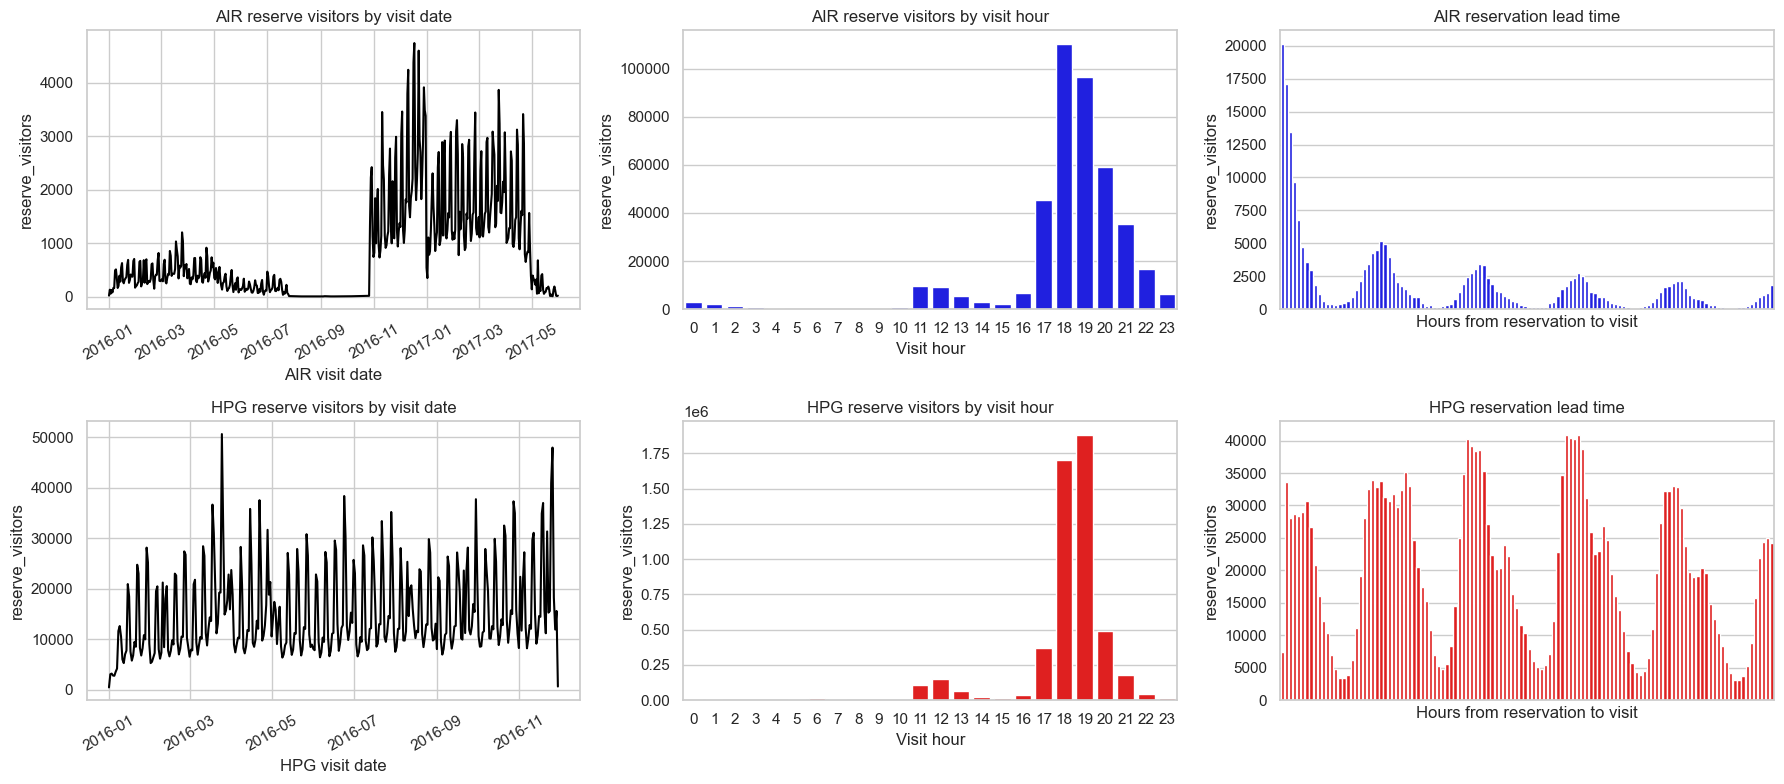

AIR reserve stores: 314
HPG reserve stores: 12721
AIR visit stores: 829
AIR store info stores: 829
Store ID relation rows: 150


In [41]:
def prepare_reserve(df, store_col):
    out = df.copy()
    out["visit_date"] = out["visit_datetime"].dt.floor("D")
    out["reserve_date"] = out["reserve_datetime"].dt.floor("D")
    out["visit_hour"] = out["visit_datetime"].dt.hour
    out["reserve_hour"] = out["reserve_datetime"].dt.hour
    out["diff_hour"] = (out["visit_datetime"] - out["reserve_datetime"]).dt.total_seconds() / 3600
    out["diff_day"] = out["diff_hour"] / 24
    return out

ar = prepare_reserve(df_ar, "air_store_id")
hr = prepare_reserve(df_hr, "hpg_store_id")

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

# AIR 예약
ar_daily = ar.groupby("visit_date", as_index=False)["reserve_visitors"].sum()
sns.lineplot(data=ar_daily, x="visit_date", y="reserve_visitors", color=BLACK, ax=axes[0, 0])
axes[0, 0].set_title("AIR reserve visitors by visit date")
axes[0, 0].set_xlabel("AIR visit date")
axes[0, 0].tick_params(axis="x", rotation=30)

ar_hour = ar.groupby("visit_hour", as_index=False)["reserve_visitors"].sum()
sns.barplot(data=ar_hour, x="visit_hour", y="reserve_visitors", color=AIR_COLOR, ax=axes[0, 1])
axes[0, 1].set_title("AIR reserve visitors by visit hour")
axes[0, 1].set_xlabel("Visit hour")

ar_diff = ar[ar["diff_hour"] < 24 * 5].groupby("diff_hour", as_index=False)["reserve_visitors"].sum()
sns.barplot(data=ar_diff, x="diff_hour", y="reserve_visitors", color=AIR_COLOR, ax=axes[0, 2])
axes[0, 2].set_title("AIR reservation lead time")
axes[0, 2].set_xlabel("Hours from reservation to visit")
axes[0, 2].set_xticks([])

# HPG 예약
hr_daily = hr.groupby("visit_date", as_index=False)["reserve_visitors"].sum()
sns.lineplot(data=hr_daily, x="visit_date", y="reserve_visitors", color=BLACK, ax=axes[1, 0])
axes[1, 0].set_title("HPG reserve visitors by visit date")
axes[1, 0].set_xlabel("HPG visit date")
axes[1, 0].tick_params(axis="x", rotation=30)

hr_hour = hr.groupby("visit_hour", as_index=False)["reserve_visitors"].sum()
sns.barplot(data=hr_hour, x="visit_hour", y="reserve_visitors", color=HPG_COLOR, ax=axes[1, 1])
axes[1, 1].set_title("HPG reserve visitors by visit hour")
axes[1, 1].set_xlabel("Visit hour")

hr_diff = hr[hr["diff_hour"] < 24 * 5].groupby("diff_hour", as_index=False)["reserve_visitors"].sum()
sns.barplot(data=hr_diff, x="diff_hour", y="reserve_visitors", color=HPG_COLOR, ax=axes[1, 2])
axes[1, 2].set_title("HPG reservation lead time")
axes[1, 2].set_xlabel("Hours from reservation to visit")
axes[1, 2].set_xticks([])

plt.tight_layout()
plt.show()

print("AIR reserve stores:", df_ar["air_store_id"].nunique())
print("HPG reserve stores:", df_hr["hpg_store_id"].nunique())
print("AIR visit stores:", df_avd["air_store_id"].nunique())
print("AIR store info stores:", df_asi["air_store_id"].nunique())
print("Store ID relation rows:", len(df_si))

**해석**

- 예약 방문 시간은 저녁 시간대에 몰리는 경향이 있습니다.
- 예약 후 방문까지의 시간은 24시간 주기성이 보입니다.
- `air_reserve`는 모든 air 식당에 존재하지 않습니다. 따라서 예약 Feature는 결측을 0으로 채우고 `has_reserve` 같은 flag를 함께 쓰는 것이 좋습니다.
- `hpg_reserve`는 `store_id_relation`을 통해 일부만 `air_store_id`와 연결할 수 있습니다.

**예측 가정**  
예약 인원 합계와 예약 건수는 실제 방문자 수 예측에 도움이 되지만, 예약 없는 식당이 많으므로 결측 자체도 중요한 정보입니다.

## 6. 식당 장르와 지역 분포

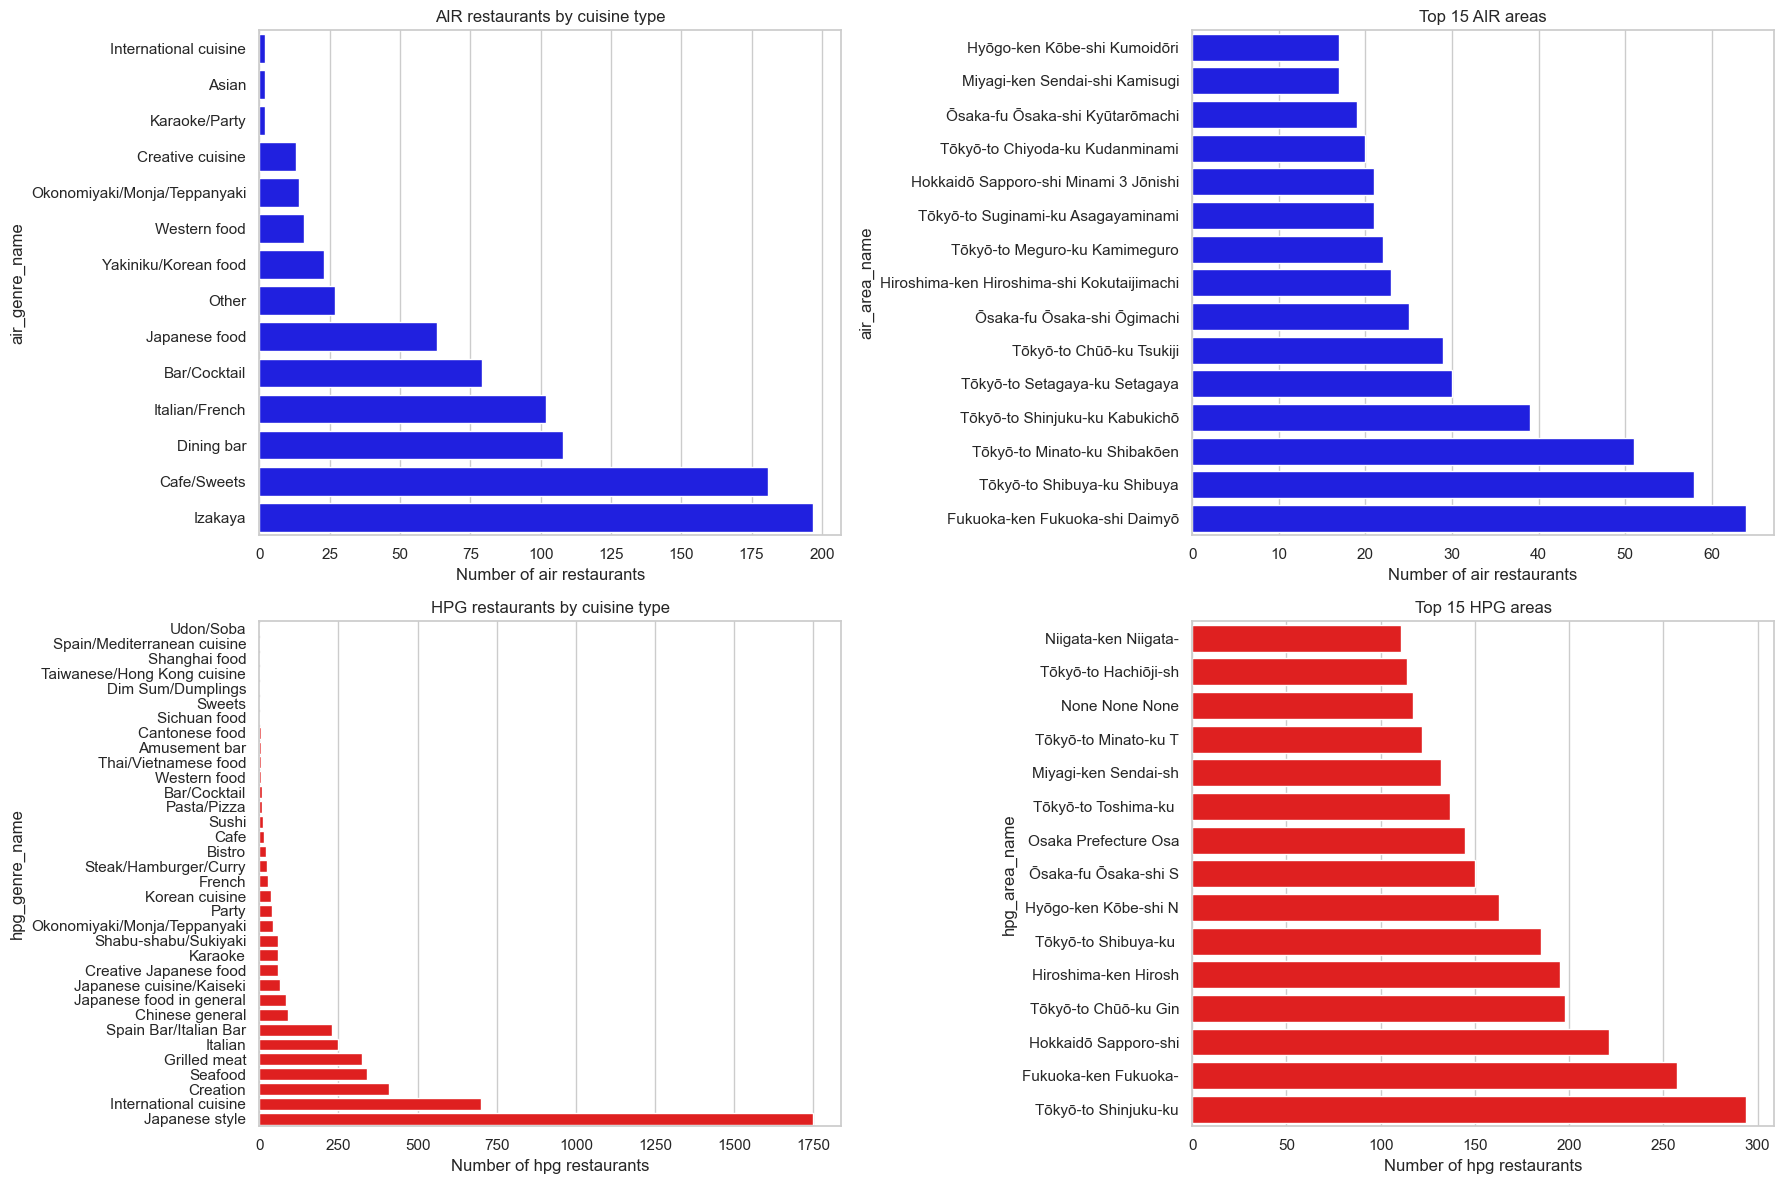

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# AIR 장르
air_genre_counts = df_asi["air_genre_name"].value_counts().sort_values()
sns.barplot(x=air_genre_counts.values, y=air_genre_counts.index, color=AIR_COLOR, ax=axes[0, 0])
axes[0, 0].set_title("AIR restaurants by cuisine type")
axes[0, 0].set_xlabel("Number of air restaurants")
axes[0, 0].set_ylabel("air_genre_name")

# AIR 지역 Top 15
air_area_counts = df_asi["air_area_name"].value_counts().head(15).sort_values()
sns.barplot(x=air_area_counts.values, y=air_area_counts.index, color=AIR_COLOR, ax=axes[0, 1])
axes[0, 1].set_title("Top 15 AIR areas")
axes[0, 1].set_xlabel("Number of air restaurants")
axes[0, 1].set_ylabel("air_area_name")

# HPG 장르
hpg_genre_counts = df_hsi["hpg_genre_name"].value_counts().sort_values()
sns.barplot(x=hpg_genre_counts.values, y=hpg_genre_counts.index, color=HPG_COLOR, ax=axes[1, 0])
axes[1, 0].set_title("HPG restaurants by cuisine type")
axes[1, 0].set_xlabel("Number of hpg restaurants")
axes[1, 0].set_ylabel("hpg_genre_name")

# HPG 지역 Top 15
hpg_area_short = df_hsi["hpg_area_name"].str.slice(0, 20)
hpg_area_counts = hpg_area_short.value_counts().head(15).sort_values()
sns.barplot(x=hpg_area_counts.values, y=hpg_area_counts.index, color=HPG_COLOR, ax=axes[1, 1])
axes[1, 1].set_title("Top 15 HPG areas")
axes[1, 1].set_xlabel("Number of hpg restaurants")
axes[1, 1].set_ylabel("hpg_area_name")

plt.tight_layout()
plt.show()

**해석**

- Air 데이터에서는 `Izakaya`, `Cafe/Sweets` 계열이 많이 등장합니다.
- HPG 데이터는 장르 분류가 더 세분화되어 있습니다.
- 지역 기준으로는 도쿄, 후쿠오카, 오사카 계열 지역이 자주 등장합니다.

**예측 가정**  
장르와 지역은 방문자 수의 기본 수준을 설명하는 Feature입니다. 특히 `air_genre_name × dayofweek` 조합이 중요할 수 있습니다.

## 7. 공휴일과 테스트 기간 구조

2016년과 2017년의 4월 말~5월 공휴일 구조, 그리고 train/test 날짜 범위를 확인합니다.

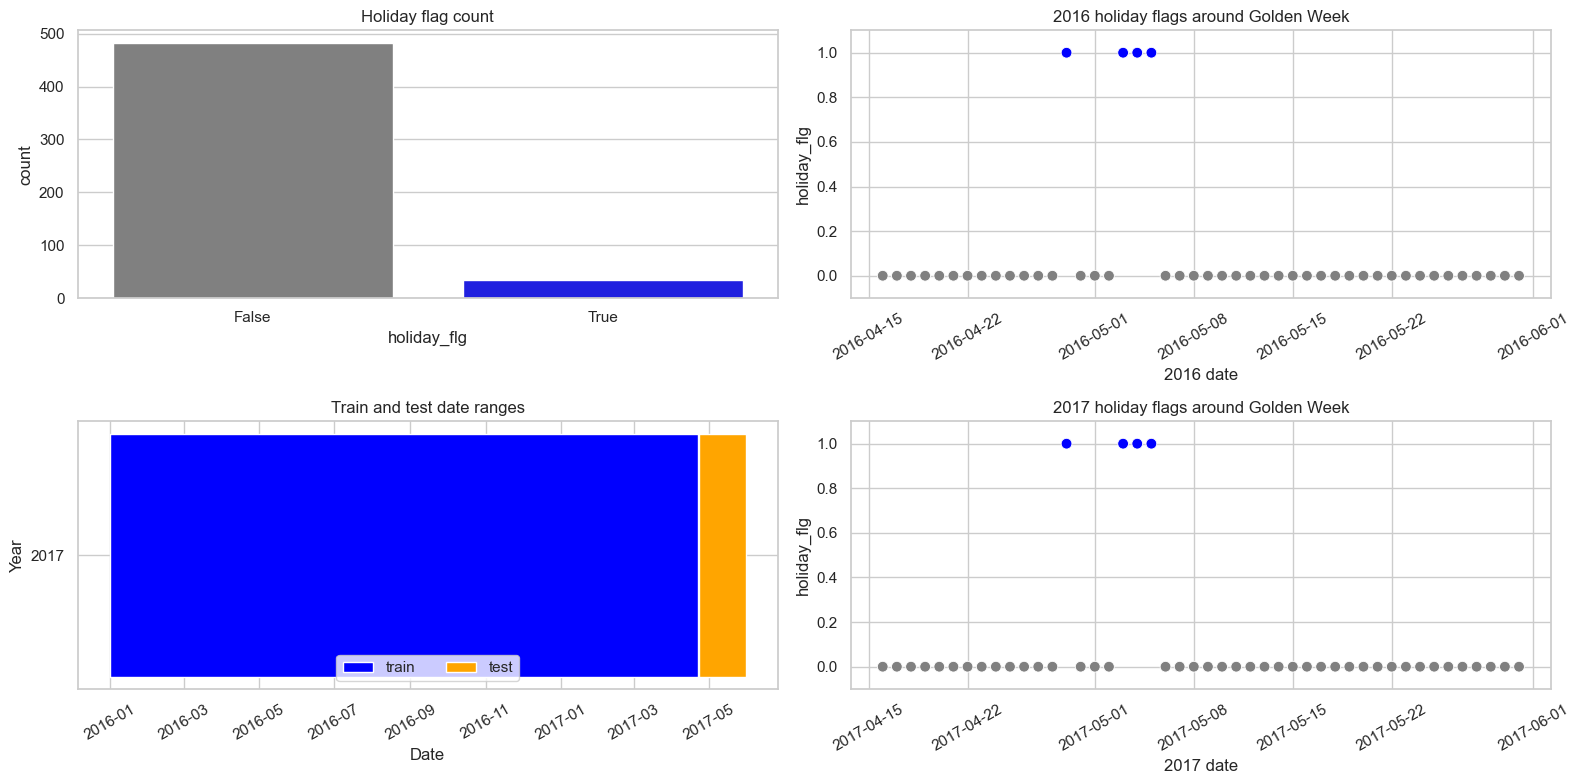

Holiday ratio: 6.77%


In [50]:
foo = df_di.copy()
foo["date"] = pd.to_datetime(foo["calendar_date"])
foo["holiday_bool"] = foo["holiday_flg"].astype(bool)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))

ax_count = axes[0, 0]
ax_2016 = axes[0, 1]
ax_range = axes[1, 0]
ax_2017 = axes[1, 1]

# 1. Holiday flag count
sns.countplot(
    data=foo,
    x="holiday_bool",
    hue="holiday_bool",
    palette=["grey", AIR_COLOR],
    legend=False,
    ax=ax_count
)

ax_count.set_title("Holiday flag count")
ax_count.set_xlabel("holiday_flg")
ax_count.set_ylabel("count")

# 2. 2016 Golden Week: 1행 2열
tmp_2016 = foo[
    (foo["date"] > pd.Timestamp("2016-04-15")) &
    (foo["date"] < pd.Timestamp("2016-06-01"))
].copy()

sns.scatterplot(
    data=tmp_2016,
    x="date",
    y="holiday_flg",
    hue="holiday_bool",
    palette=["grey", AIR_COLOR],
    s=60,
    legend=False,
    ax=ax_2016
)

ax_2016.set_title("2016 holiday flags around Golden Week")
ax_2016.set_xlabel("2016 date")
ax_2016.set_ylabel("holiday_flg")
ax_2016.set_ylim(-0.1, 1.1)
ax_2016.tick_params(axis="x", rotation=30)

# 3. Train and test date ranges: 2행 1열
train_min = df_avd["visit_date"].min()
train_max = df_avd["visit_date"].max()

test_min = df_ss["visit_date"].min()
test_max = df_ss["visit_date"].max()

train_start = mdates.date2num(train_min)
train_width = mdates.date2num(train_max) - mdates.date2num(train_min)

test_start = mdates.date2num(test_min)
test_width = mdates.date2num(test_max) - mdates.date2num(test_min)

ax_range.broken_barh(
    [(train_start, train_width)],
    (15, 8),
    facecolors=AIR_COLOR,
    label="train"
)

ax_range.broken_barh(
    [(test_start, test_width)],
    (15, 8),
    facecolors="orange",
    label="test"
)

ax_range.set_title("Train and test date ranges")
ax_range.set_xlabel("Date")
ax_range.set_ylabel("Year")
ax_range.set_yticks([19])
ax_range.set_yticklabels(["2017"])

ax_range.xaxis_date()
ax_range.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_range.tick_params(axis="x", rotation=30)
ax_range.legend(loc="lower center", ncol=2)

# 4. 2017 Golden Week: 2행 2열
tmp_2017 = foo[
    (foo["date"] > pd.Timestamp("2017-04-15")) &
    (foo["date"] < pd.Timestamp("2017-06-01"))
].copy()

sns.scatterplot(
    data=tmp_2017,
    x="date",
    y="holiday_flg",
    hue="holiday_bool",
    palette=["grey", AIR_COLOR],
    s=60,
    legend=False,
    ax=ax_2017
)

ax_2017.set_title("2017 holiday flags around Golden Week")
ax_2017.set_xlabel("2017 date")
ax_2017.set_ylabel("holiday_flg")
ax_2017.set_ylim(-0.1, 1.1)
ax_2017.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

holiday_ratio = foo["holiday_flg"].mean()
print(f"Holiday ratio: {holiday_ratio:.2%}")

**해석**

- 전체 날짜 중 공휴일 비율은 약 7%
- 2016년과 2017년 Golden Week와 겹칩니다.
- 2016년 4월 말과 5월은 2017년과 휴일이 같습니다.

**예측 가정**  
단순 `holiday_flg`보다 `holiday_flg × dayofweek`, `is_golden_week`가 더 유용할 가능성이 큽니다.

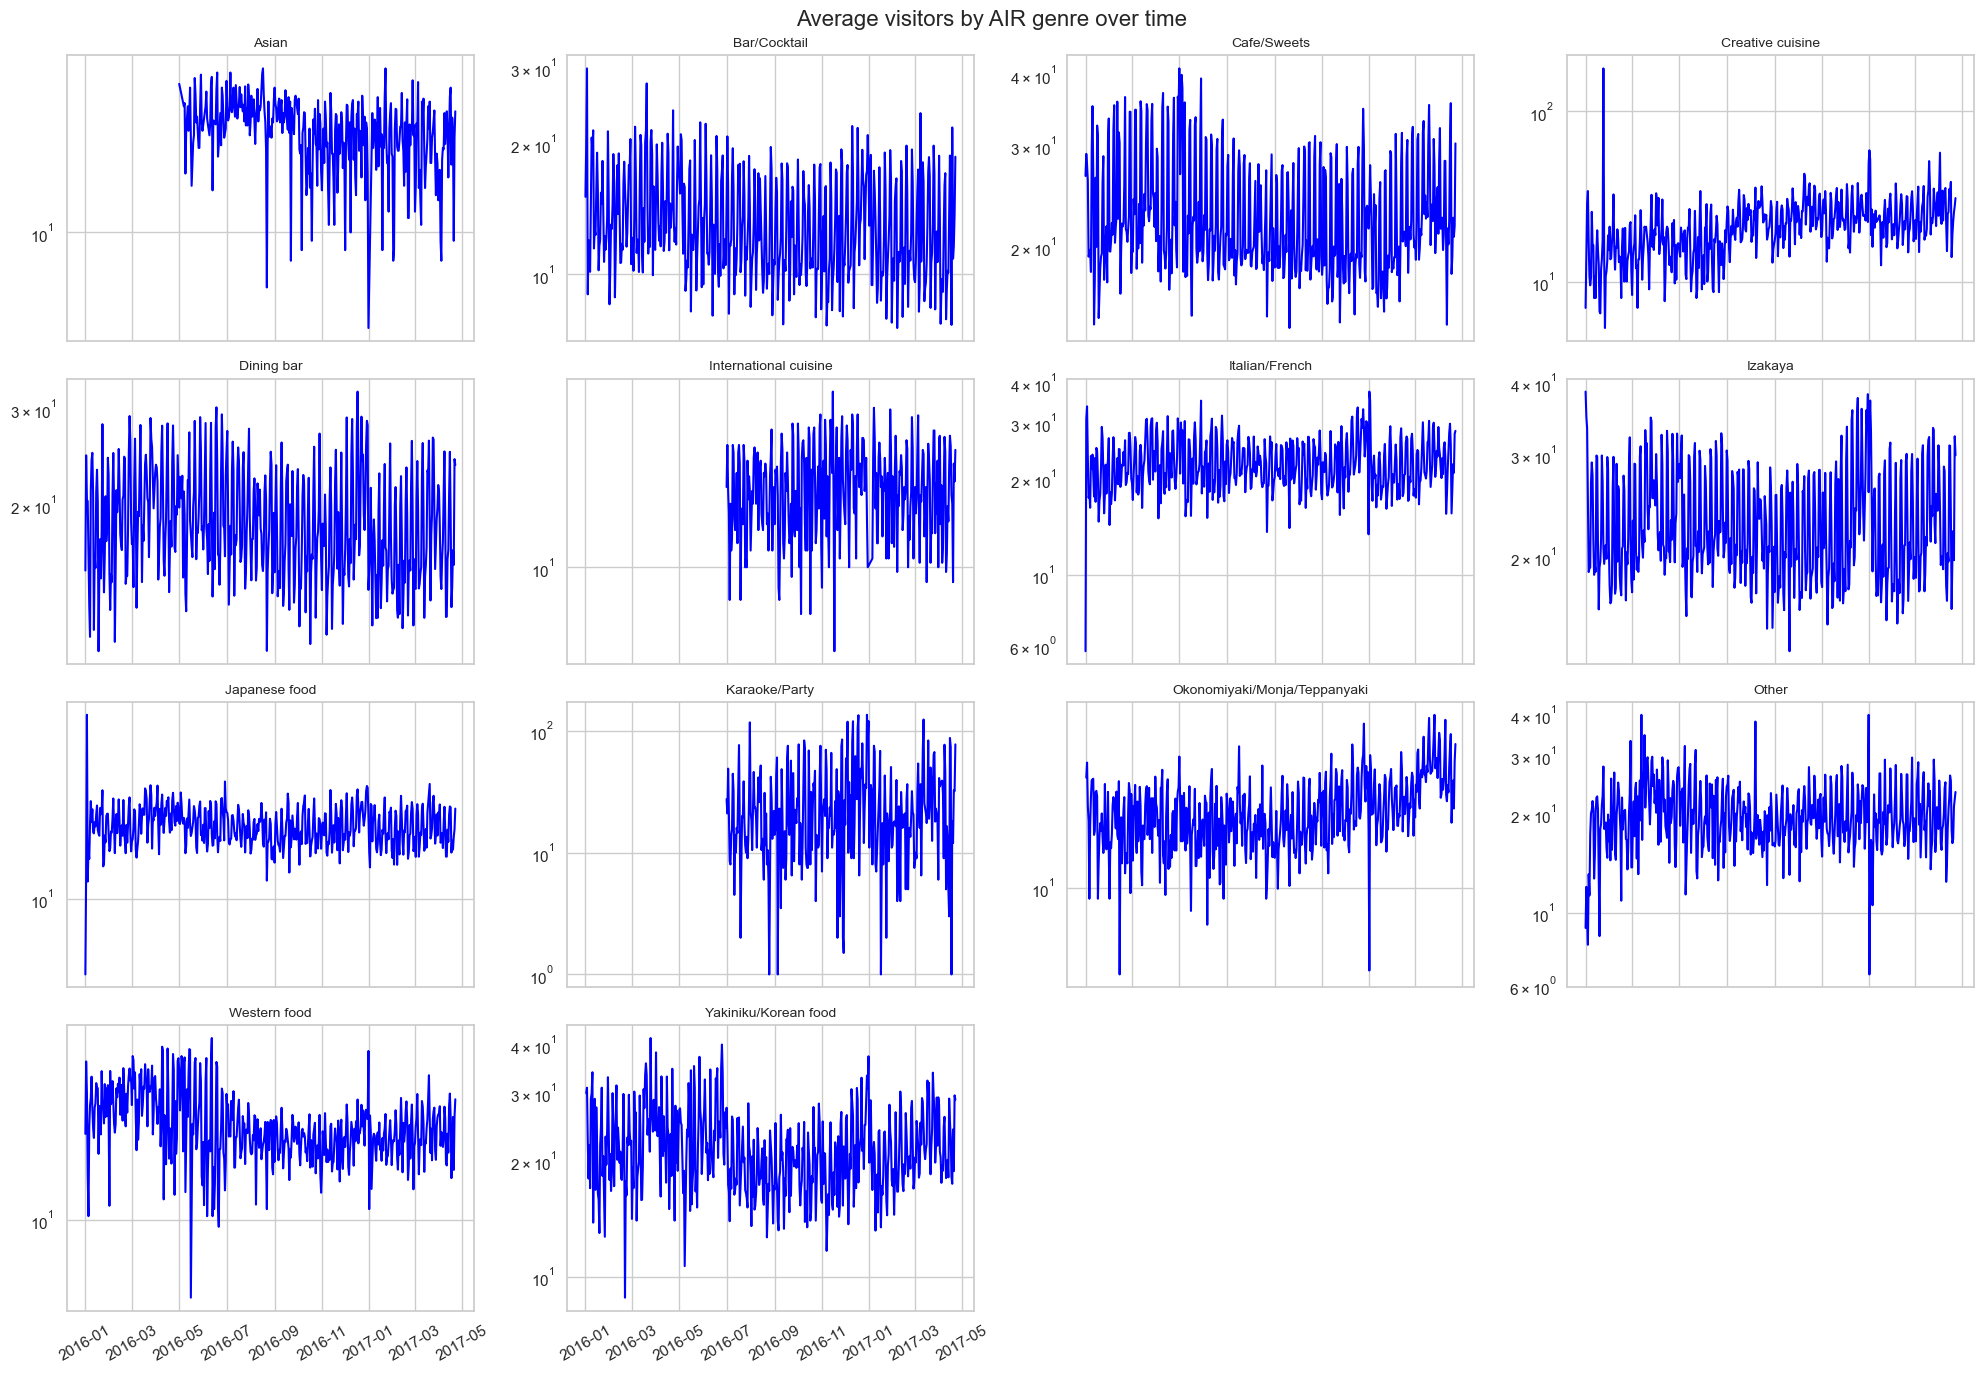

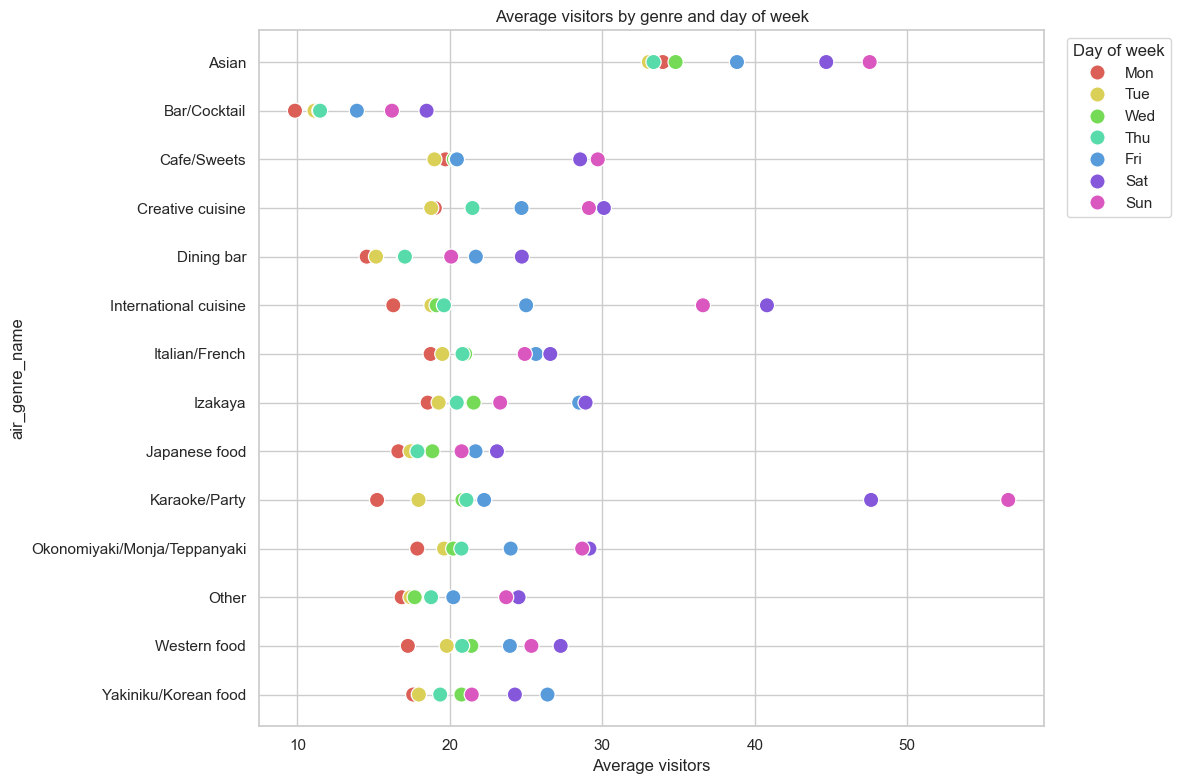

In [44]:
avd_store = df_avd.merge(df_asi, on="air_store_id", how="left")

# 장르별 일평균 방문자 수 시계열: facet
fig, axes = plt.subplots(4, 4, figsize=(20, 14), sharex=True)
axes = axes.flatten()

genres = sorted(avd_store["air_genre_name"].dropna().unique())
for ax, genre in zip(axes, genres):
    tmp = (
        avd_store[avd_store["air_genre_name"] == genre]
        .groupby("visit_date", as_index=False)["visitors"]
        .mean()
        .rename(columns={"visitors": "mean_visitors"})
    )
    sns.lineplot(data=tmp, x="visit_date", y="mean_visitors", color=AIR_COLOR, ax=ax)
    ax.set_title(genre, fontsize=10)
    ax.set_yscale("log")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)

for i in range(len(genres), len(axes)):
    axes[i].axis("off")

fig.suptitle("Average visitors by AIR genre over time", fontsize=16)
plt.tight_layout()
plt.show()

# 장르 x 요일 평균 방문자 수: 원본의 point plot 방향 유지
genre_dow = (
    avd_store
    .groupby(["air_genre_name", "dow_name"], observed=False)["visitors"]
    .mean()
    .reset_index()
    .rename(columns={"visitors": "mean_visitors"})
)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=genre_dow,
    x="mean_visitors",
    y="air_genre_name",
    hue="dow_name",
    hue_order=dow_order,
    palette="hls",
    s=120
)
plt.title("Average visitors by genre and day of week")
plt.xlabel("Average visitors")
plt.ylabel("air_genre_name")
plt.legend(title="Day of week", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**해석**

- 장르별 평균 방문자 수는 대체로 안정적이지만, 일부 장르는 변동성이 큽니다.
- 모든 장르에서 주간 패턴이 보이며, 특히 주말 효과가 강한 장르가 있습니다.
- `Karaoke`, `International cuisine`처럼 요일별 차이가 큰 장르는 별도 상호작용 Feature가 유효할 수 있습니다.
- 주중.주말 갭이 가장 적은 곳은 ‘Other’, ’Japanese food’이고, ’Korean food’는 금요일이 평균 방문객이 가장 많습니다. ’Bar/Cocktail’은 전반적으로 방문객이 적습니다.
-  ‘Asian’ 레스토랑은 평균 방문객수가 10명 미만이 거의 없고, ’Karaoke’는 강한 주말의 영향으로 분포가 넓습니다.

**예측 가정**  
`air_genre_name`, `dayofweek`, `air_genre_name × dayofweek`는 모델 성능 향상에 도움이 됩니다.

## 9. 공휴일 효과: 전체보다 요일별 효과가 중요

휴일 효과가 단독으로 크지 않아 보여도, 요일별로 보면 차이가 있습니다. 

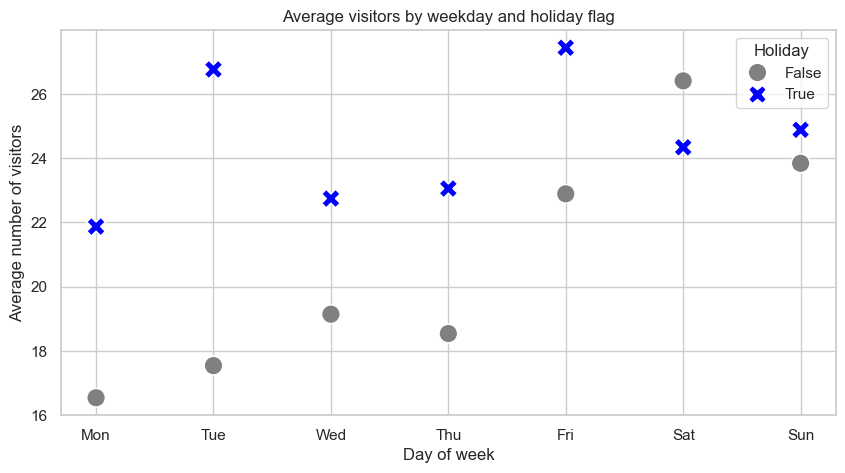

holiday_bool,False,True
dow_name,,
Mon,16.541359,21.869048
Tue,17.542357,26.761341
Wed,19.141512,22.741722
Thu,18.540014,23.054331
Fri,22.889265,27.436732
Sat,26.406175,24.338269
Sun,23.839388,24.882293


In [45]:
holiday_join = df_avd.merge(
    df_di[["calendar_date", "day_of_week", "holiday_flg"]],
    left_on="visit_date",
    right_on="calendar_date",
    how="left"
)

holiday_join["holiday_bool"] = holiday_join["holiday_flg"].astype(bool)

holiday_dow = (
    holiday_join
    .groupby(["dow_name", "holiday_bool"], observed=False)["visitors"]
    .mean()
    .reset_index()
    .rename(columns={"visitors": "mean_visitors"})
)

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=holiday_dow,
    x="dow_name",
    y="mean_visitors",
    hue="holiday_bool",
    style="holiday_bool",
    s=180,
    palette=[GREY, AIR_COLOR]
)
plt.title("Average visitors by weekday and holiday flag")
plt.xlabel("Day of week")
plt.ylabel("Average number of visitors")
plt.legend(title="Holiday")
plt.show()

display(holiday_dow.pivot(index="dow_name", columns="holiday_bool", values="mean_visitors").loc[dow_order])

**해석**

- 휴일 효과는 단독으로 보면 약할 수 있습니다.
- 하지만 평일이 휴일이 되는 경우에는 방문자 수가 달라질 수 있습니다.
- 주말 공휴일은 이미 주말 효과가 반영되어 있어 추가 효과가 작거나 반대로 나타날 수 있습니다.

**예측 가정**  
`holiday_flg` 단독보다 `dayofweek × holiday_flg`가 더 중요합니다.

## 10. 지역 × 장르 분포
  
어떤 지역에 어떤 장르가 얼마나 있는지 확인합니다. 점의 크기는 해당 조합의 식당 수입니다.

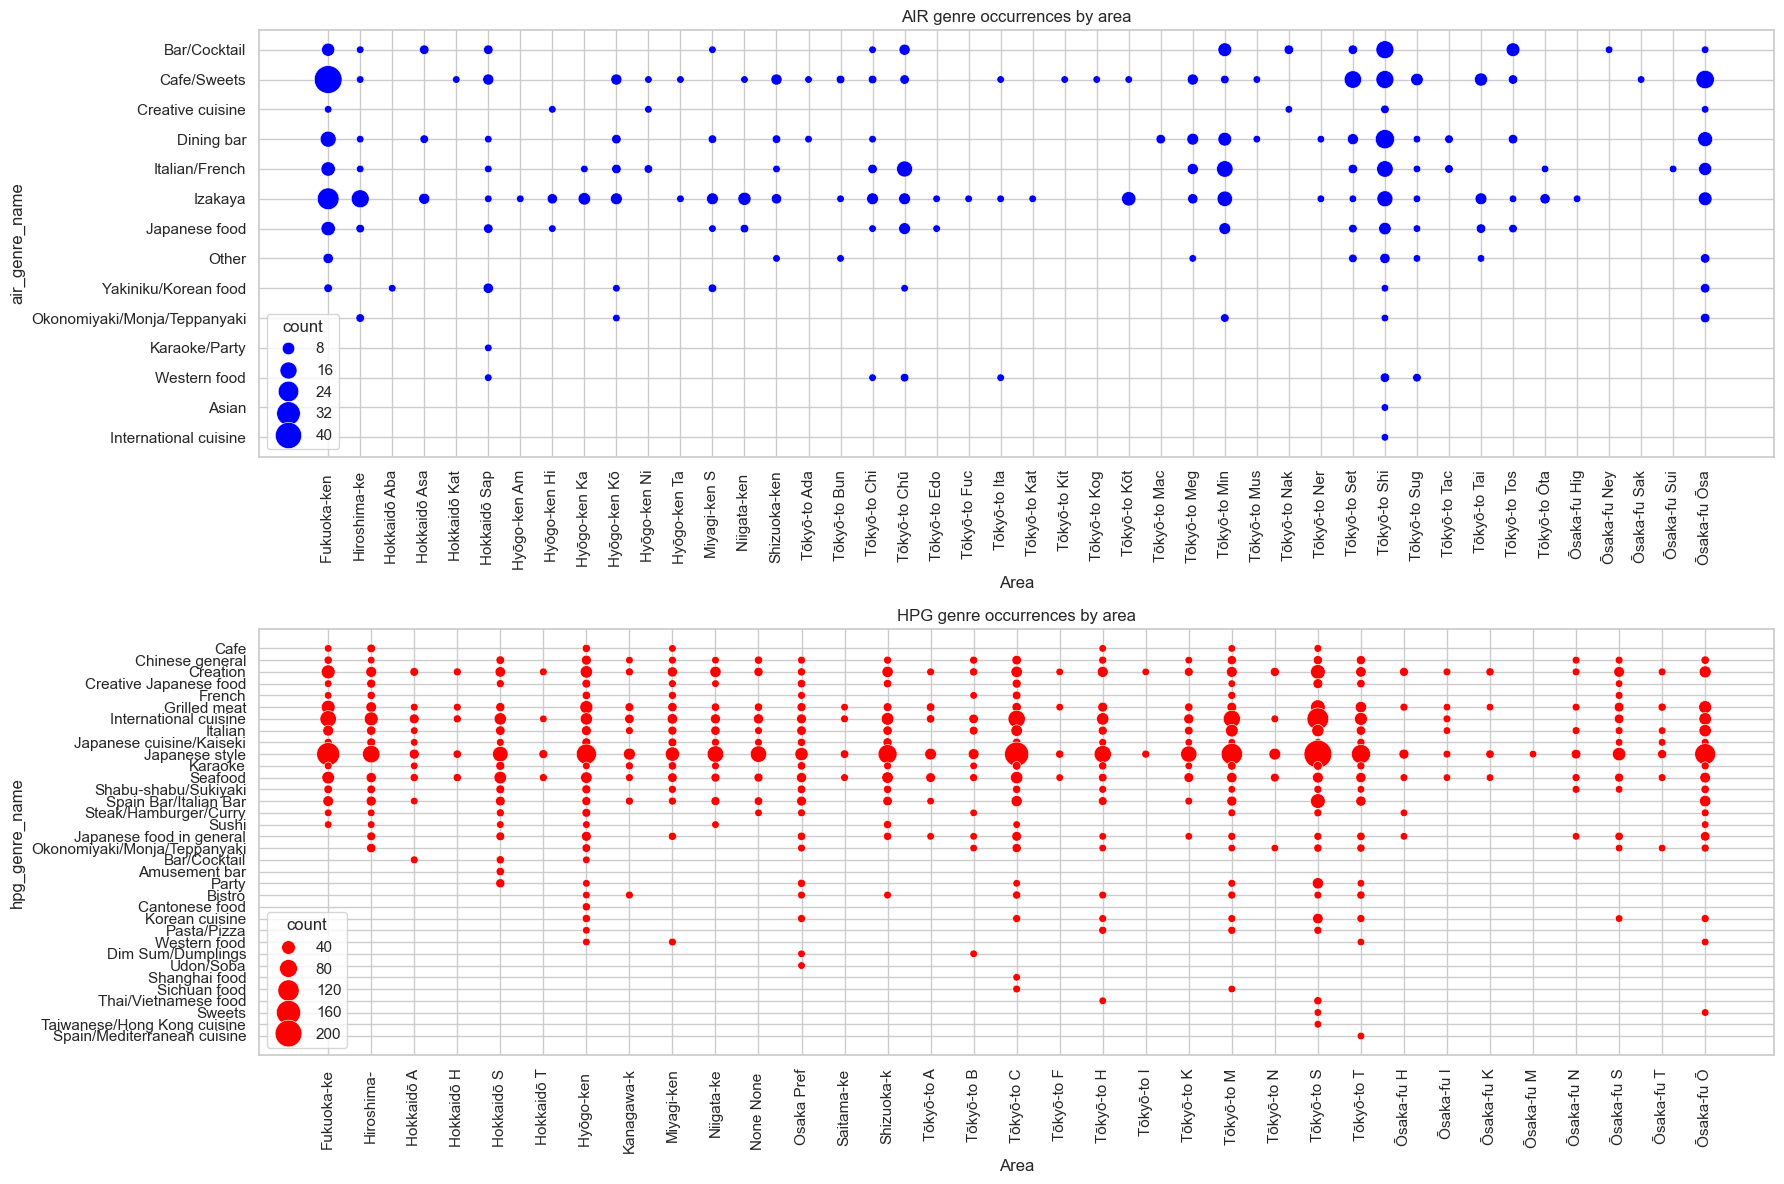

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# AIR 지역-장르 count plot
air_area_genre = (
    df_asi.assign(area=df_asi["air_area_name"].str.slice(0, 12))
    .groupby(["area", "air_genre_name"])
    .size()
    .reset_index(name="count")
)

sns.scatterplot(
    data=air_area_genre,
    x="area",
    y="air_genre_name",
    size="count",
    sizes=(30, 400),
    color=AIR_COLOR,
    legend="brief",
    ax=axes[0]
)
axes[0].set_title("AIR genre occurrences by area")
axes[0].set_xlabel("Area")
axes[0].set_ylabel("air_genre_name")
axes[0].tick_params(axis="x", rotation=90)

# HPG 지역-장르 count plot
hpg_area_genre = (
    df_hsi.assign(area=df_hsi["hpg_area_name"].str.slice(0, 10))
    .groupby(["area", "hpg_genre_name"])
    .size()
    .reset_index(name="count")
)

sns.scatterplot(
    data=hpg_area_genre,
    x="area",
    y="hpg_genre_name",
    size="count",
    sizes=(30, 400),
    color=HPG_COLOR,
    legend="brief",
    ax=axes[1]
)
axes[1].set_title("HPG genre occurrences by area")
axes[1].set_xlabel("Area")
axes[1].set_ylabel("hpg_genre_name")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

**해석**

- 특정 지역에는 다양한 장르가 모여 있고, 어떤 지역은 장르가 매우 제한적입니다.
- 몇 몇 지역에는 많고 다양한 레스토랑이 있지만, 어떤 지역에는 하나의 레스토랑만 있습니다. parameter 공간의 대부분은 비어있습니다.
- 장르와 지역의 조합은 식당의 경쟁 환경이나 수요 특성을 간접적으로 나타낼 수 있습니다.

**예측 가정**  
`area별 식당 수`, `area × genre별 식당 수`는 방문자 수의 기본 수준을 보정하는 Feature가 될 수 있습니다.

## 11. 예약자 수와 실제 방문자 수 관계

Air 예약과 HPG 예약을 모두 `air_store_id` 기준으로 맞춘 뒤, 실제 방문자 수와 비교

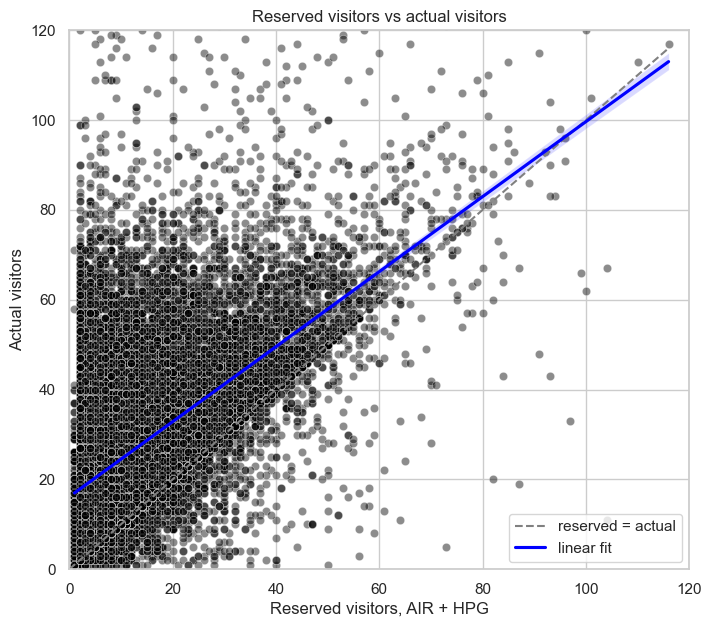

,count,mean,median,std
has_reserve,,,,
0,218535,20.094694,16.0,16.330101
1,33573,26.695827,23.0,18.302418


In [47]:
# AIR 예약: 식당-방문일 단위 집계
air_reserve_daily = (
    ar.groupby(["air_store_id", "visit_date"], as_index=False)
    .agg(
        reserve_visitors_air=("reserve_visitors", "sum"),
        reserve_count_air=("reserve_visitors", "count"),
        diff_day_air=("diff_day", "mean")
    )
)

# HPG 예약: hpg_store_id를 air_store_id로 연결 후 식당-방문일 단위 집계
hr_mapped = hr.merge(df_si, on="hpg_store_id", how="inner")
hpg_reserve_daily = (
    hr_mapped.groupby(["air_store_id", "visit_date"], as_index=False)
    .agg(
        reserve_visitors_hpg=("reserve_visitors", "sum"),
        reserve_count_hpg=("reserve_visitors", "count"),
        diff_day_hpg=("diff_day", "mean")
    )
)

all_reserve = (
    df_avd
    .merge(air_reserve_daily, on=["air_store_id", "visit_date"], how="left")
    .merge(hpg_reserve_daily, on=["air_store_id", "visit_date"], how="left")
)

reserve_fill_cols = ["reserve_visitors_air", "reserve_count_air", "diff_day_air", "reserve_visitors_hpg", "reserve_count_hpg", "diff_day_hpg"]
for col in reserve_fill_cols:
    all_reserve[col] = all_reserve[col].fillna(0)

all_reserve["reserve_visitors"] = all_reserve["reserve_visitors_air"] + all_reserve["reserve_visitors_hpg"]
all_reserve["has_reserve"] = (all_reserve["reserve_visitors"] > 0).astype(int)

plot_df = all_reserve[all_reserve["reserve_visitors"] > 0].copy()
plot_df = plot_df[plot_df["reserve_visitors"] < 120]

plt.figure(figsize=(8, 7))
sns.scatterplot(data=plot_df, x="reserve_visitors", y="visitors", color=BLACK, alpha=0.45)

# identity line
max_val = min(120, max(plot_df["reserve_visitors"].max(), plot_df["visitors"].quantile(0.98)))
plt.plot([0, max_val], [0, max_val], color="grey", linestyle="--", label="reserved = actual")

# linear fit
sns.regplot(data=plot_df, x="reserve_visitors", y="visitors", scatter=False, color=AIR_COLOR, label="linear fit")

plt.title("Reserved visitors vs actual visitors")
plt.xlabel("Reserved visitors, AIR + HPG")
plt.ylabel("Actual visitors")
plt.xlim(0, 120)
plt.ylim(0, max(120, plot_df["visitors"].quantile(0.99)))
plt.legend()
plt.show()

reserve_stats = all_reserve.groupby("has_reserve")["visitors"].agg(["count", "mean", "median", "std"])
display(reserve_stats)

**해석**

- 예약자 수와 실제 방문자 수는 양의 관계가 있습니다.
- 하지만 많은 점이 `reserved = actual` 선 위에 있습니다. 즉, 예약하지 않고 방문하는 고객이 많습니다.
- 반대로 예약자 수보다 실제 방문자가 적은 경우도 있어 no-show나 예약 취소 가능성을 고려해야 합니다.

**예측 가정**  
예약 관련 Feature는 `reserve_visitors_sum`, `reserve_count`, `diff_day_mean`, `has_reserve` 형태로 집계해서 사용하는 것이 좋습니다.

## 12. 모델링에 바로 쓸 수 있는 핵심 Feature 후보

EDA에서 도출한 가정을 코드로 정리합니다.  
아래 Feature는 다음 모델링 단계에서 train/test에 병합해 사용할 수 있습니다.

In [48]:
# Golden Week Feature

def is_golden_week(date):
    return int((date.month == 4 and date.day >= 29) or (date.month == 5 and date.day <= 5))

# 공휴일 주변 Feature
date_features = df_di.copy()
date_features = date_features.sort_values("calendar_date")
date_features["is_golden_week"] = date_features["calendar_date"].apply(is_golden_week)
date_features["before_holiday"] = date_features["holiday_flg"].shift(-1).fillna(0).astype(int)
date_features["after_holiday"] = date_features["holiday_flg"].shift(1).fillna(0).astype(int)

# 식당별 기본 통계
store_stats = (
    df_avd.groupby("air_store_id")["visitors"]
    .agg(
        store_mean="mean",
        store_median="median",
        store_min="min",
        store_max="max",
        store_count="count"
    )
    .reset_index()
)

# 식당 x 요일 통계
store_dow_stats = (
    df_avd.groupby(["air_store_id", "dayofweek"])["visitors"]
    .agg(
        store_dow_mean="mean",
        store_dow_median="median",
        store_dow_min="min",
        store_dow_max="max",
        store_dow_count="count"
    )
    .reset_index()
)

# 지역별 식당 수, 지역 x 장르별 식당 수
air_area_count = (
    df_asi.groupby("air_area_name")
    .size()
    .reset_index(name="air_area_count")
)

air_area_genre_count = (
    df_asi.groupby(["air_area_name", "air_genre_name"])
    .size()
    .reset_index(name="air_area_genre_count")
)

# Feature 후보 미리보기
display(date_features.head())
display(store_stats.head())
display(store_dow_stats.head())
display(air_area_count.head())
display(air_area_genre_count.head())

,calendar_date,day_of_week,holiday_flg,is_golden_week,before_holiday,after_holiday
0,2016-01-01,Friday,1,0,1,0
1,2016-01-02,Saturday,1,0,1,1
2,2016-01-03,Sunday,1,0,0,1
3,2016-01-04,Monday,0,0,0,1
4,2016-01-05,Tuesday,0,0,0,0


,air_store_id,store_mean,store_median,store_min,store_max,store_count
0,air_00a91d42b08b08d9,26.081897,26.0,1,99,232
1,air_0164b9927d20bcc3,9.248322,8.0,1,27,149
2,air_0241aa3964b7f861,9.896465,9.0,1,48,396
3,air_0328696196e46f18,7.939655,6.0,1,41,116
4,air_034a3d5b40d5b1b1,14.828685,12.0,1,116,251


,air_store_id,dayofweek,store_dow_mean,store_dow_median,store_dow_min,store_dow_max,store_dow_count
0,air_00a91d42b08b08d9,0,22.457143,19.0,1,47,35
1,air_00a91d42b08b08d9,1,24.350000,24.5,1,43,40
2,air_00a91d42b08b08d9,2,28.125000,28.0,15,52,40
3,air_00a91d42b08b08d9,3,29.868421,30.0,15,47,38
4,air_00a91d42b08b08d9,4,36.500000,35.5,17,57,40


,air_area_name,air_area_count
0,Fukuoka-ken Fukuoka-shi Daimyō,64
1,Fukuoka-ken Fukuoka-shi Hakata Ekimae,16
2,Fukuoka-ken Fukuoka-shi Imaizumi,2
3,Fukuoka-ken Fukuoka-shi Momochi,6
4,Fukuoka-ken Fukuoka-shi Shiobaru,7


,air_area_name,air_genre_name,air_area_genre_count
0,Fukuoka-ken Fukuoka-shi Daimyō,Bar/Cocktail,7
1,Fukuoka-ken Fukuoka-shi Daimyō,Cafe/Sweets,26
2,Fukuoka-ken Fukuoka-shi Daimyō,Creative cuisine,2
3,Fukuoka-ken Fukuoka-shi Daimyō,Dining bar,5
4,Fukuoka-ken Fukuoka-shi Daimyō,Italian/French,9


**핵심 Feature 가정 요약**

| 구분 | Feature 후보 | 기대 효과 |
|---|---|---|
| 날짜 | `dayofweek`, `month`, `is_weekend` | 요일/월별 계절성 반영 |
| 공휴일 | `holiday_flg`, `before_holiday`, `after_holiday`, `is_golden_week` | Golden Week와 휴일 효과 반영 |
| 식당 | `store_mean`, `store_median`, `store_count` | 식당별 기본 방문 수준 반영 |
| 식당×요일 | `store_dow_mean`, `store_dow_median` | 가장 강력한 baseline 후보 |
| 장르 | `air_genre_name` | 업종별 방문 수준 차이 반영 |
| 지역 | `air_area_name`, `air_area_count` | 지역 수요/밀집도 반영 |
| 지역×장르 | `air_area_genre_count` | 동일 지역 경쟁/수요 특성 반영 |
| 예약 | `reserve_visitors`, `reserve_count`, `diff_day`, `has_reserve` | 예약 기반 수요 반영 |

다음 단계에서는 이 Feature들을 train/test에 동일하게 병합한 뒤, `log1p(visitors)`를 타깃으로 LightGBM/CatBoost baseline을 만들면 좋습니다.

## 13. 수치형 변수 간 상관관계 확인

상관관계는 선형 관계만 보여주므로 한계가 있지만, 예약 관련 변수와 날짜/휴일 변수가 타깃과 어떤 방향성을 가지는지 빠르게 확인할 수 있습니다.

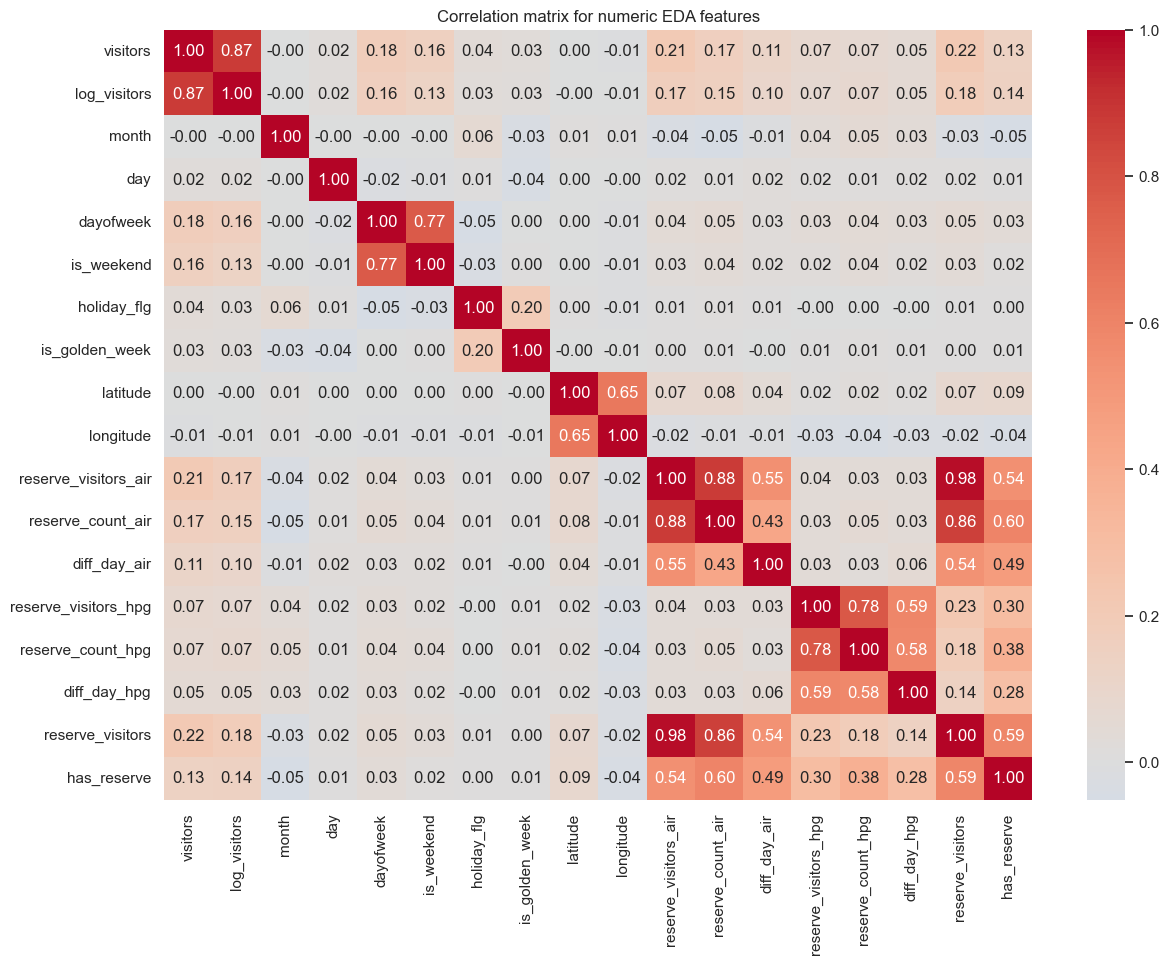

,feature,corr_with_log_visitors
0,log_visitors,1.000000
1,visitors,0.873697
2,reserve_visitors,0.183129
3,reserve_visitors_air,0.174332
4,dayofweek,0.162690
5,reserve_count_air,0.153110
6,has_reserve,0.143850
7,is_weekend,0.133623
8,diff_day_air,0.100589
9,reserve_count_hpg,0.074075


In [49]:
eda_corr = (
    all_reserve
    .merge(df_di[["calendar_date", "holiday_flg"]], left_on="visit_date", right_on="calendar_date", how="left")
    .merge(df_asi[["air_store_id", "latitude", "longitude"]], on="air_store_id", how="left")
)

eda_corr["is_golden_week"] = eda_corr["visit_date"].apply(is_golden_week)
eda_corr["log_visitors"] = np.log1p(eda_corr["visitors"])

corr_cols = [
    "visitors", "log_visitors", "month", "day", "dayofweek", "is_weekend",
    "holiday_flg", "is_golden_week", "latitude", "longitude",
    "reserve_visitors_air", "reserve_count_air", "diff_day_air",
    "reserve_visitors_hpg", "reserve_count_hpg", "diff_day_hpg",
    "reserve_visitors", "has_reserve"
]

corr_matrix = eda_corr[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix for numeric EDA features")
plt.show()

corr_target = corr_matrix["log_visitors"].sort_values(ascending=False).reset_index()
corr_target.columns = ["feature", "corr_with_log_visitors"]
display(corr_target)

**해석**

- 예약 관련 변수는 실제 방문자 수와 양의 관계를 가질 가능성이 큽니다.
- 단순 상관계수가 낮더라도, `식당×요일`, `장르×요일`, `휴일×요일`처럼 비선형 상호작용이 중요한 경우가 많습니다.
- 트리 기반 모델은 이런 상호작용을 어느 정도 자동으로 학습할 수 있습니다.


# 14. 머신러닝 전처리: EDA 결과를 Feature로 변환

지금까지 EDA에서 확인한 핵심은 다음입니다.

- 방문자 수는 식당별 기본 수준 차이가 큽니다.
- 같은 식당이라도 요일별 방문 패턴이 다릅니다.
- 공휴일 효과는 단독보다 요일, Golden Week와 함께 볼 때 중요합니다.
- 예약자 수와 예약 건수는 실제 방문자 수와 관련이 있습니다.
- 장르와 지역은 식당의 기본 방문 규모와 요일 패턴을 설명하는 데 도움이 됩니다.

따라서 머신러닝 전에 아래 전처리를 수행합니다.

1. `air_visit_data`와 `sample_submission`을 같은 구조로 통합합니다.
2. 날짜, 공휴일, Golden Week Feature를 추가합니다.
3. 식당 장르/지역 정보를 결합합니다.
4. `air_reserve`, `hpg_reserve`를 식당-날짜 단위로 집계합니다.
5. 과거 방문 데이터를 이용해 식당별, 요일별, 장르별 통계 Feature를 만듭니다.
6. 모델링에 불필요하거나 누수를 만들 수 있는 컬럼을 분리합니다.



## 14-1. Train/Test 기본 테이블 통합

`sample_submission.csv`의 `id`는 `air_store_id_날짜` 구조입니다.  
모델은 train과 test를 같은 Feature 구조로 가져야 하므로, 먼저 두 데이터를 하나의 `df_all`로 통합합니다.

**효과**

- train/test에 동일한 전처리 코드를 적용할 수 있습니다.
- Feature 생성 과정에서 컬럼 누락이나 순서 불일치 문제를 줄일 수 있습니다.
- test의 `visitors`는 예측 대상이므로 `NaN`으로 둡니다.


In [ ]:

# 날짜 타입을 다시 한 번 안전하게 변환
df_avd["visit_date"] = pd.to_datetime(df_avd["visit_date"])
df_di["calendar_date"] = pd.to_datetime(df_di["calendar_date"])

df_ar["visit_datetime"] = pd.to_datetime(df_ar["visit_datetime"])
df_ar["reserve_datetime"] = pd.to_datetime(df_ar["reserve_datetime"])

df_hr["visit_datetime"] = pd.to_datetime(df_hr["visit_datetime"])
df_hr["reserve_datetime"] = pd.to_datetime(df_hr["reserve_datetime"])

# sample_submission의 id에서 air_store_id와 visit_date 추출
df_ss = df_ss.copy()
id_split = df_ss["id"].str.rsplit("_", n=1, expand=True)
df_ss["air_store_id"] = id_split[0]
df_ss["visit_date"] = pd.to_datetime(id_split[1])

# train 기본 테이블
train_base = df_avd[["air_store_id", "visit_date", "visitors"]].copy()
train_base["id"] = (
    train_base["air_store_id"] + "_" +
    train_base["visit_date"].dt.strftime("%Y-%m-%d")
)
train_base["dset"] = "train"
train_base["log_visitors"] = np.log1p(train_base["visitors"])

# test 기본 테이블
test_base = df_ss[["id", "air_store_id", "visit_date"]].copy()
test_base["visitors"] = np.nan
test_base["log_visitors"] = np.nan
test_base["dset"] = "test"

# train/test 통합
df_all = pd.concat([train_base, test_base], axis=0, ignore_index=True)

print("train_base:", train_base.shape)
print("test_base :", test_base.shape)
print("df_all    :", df_all.shape)

df_all.head()



## 14-2. 날짜, 공휴일, Golden Week Feature 추가

EDA에서 요일, 주말, 공휴일, Golden Week가 방문자 수에 영향을 줄 가능성이 높았습니다.  
특히 테스트 기간이 2017년 4월 말~5월이고 Golden Week가 포함되어 있으므로, 일반적인 날짜 Feature 외에 Golden Week 여부를 별도로 만듭니다.

**효과**

- 요일별 방문 패턴을 학습할 수 있습니다.
- 공휴일 전후의 수요 변화를 반영할 수 있습니다.
- Golden Week처럼 특수한 기간을 일반 평일/주말과 구분할 수 있습니다.


In [ ]:

def is_golden_week(date):
    return int((date.month == 4 and date.day >= 29) or (date.month == 5 and date.day <= 5))

# 기본 날짜 Feature
df_all["year"] = df_all["visit_date"].dt.year
df_all["month"] = df_all["visit_date"].dt.month
df_all["day"] = df_all["visit_date"].dt.day
df_all["dayofweek"] = df_all["visit_date"].dt.dayofweek  # 월=0, 일=6
df_all["weekofyear"] = df_all["visit_date"].dt.isocalendar().week.astype(int)
df_all["is_weekend"] = df_all["dayofweek"].isin([5, 6]).astype(int)
df_all["is_month_start"] = df_all["visit_date"].dt.is_month_start.astype(int)
df_all["is_month_end"] = df_all["visit_date"].dt.is_month_end.astype(int)
df_all["is_golden_week"] = df_all["visit_date"].apply(is_golden_week)

# 선형 모델에도 요일/월의 순환 구조를 반영할 수 있도록 sin/cos Feature 생성
df_all["dow_sin"] = np.sin(2 * np.pi * df_all["dayofweek"] / 7)
df_all["dow_cos"] = np.cos(2 * np.pi * df_all["dayofweek"] / 7)
df_all["month_sin"] = np.sin(2 * np.pi * df_all["month"] / 12)
df_all["month_cos"] = np.cos(2 * np.pi * df_all["month"] / 12)

# 공휴일 Feature
date_features = df_di.copy().sort_values("calendar_date")
date_features["visit_date"] = date_features["calendar_date"]
date_features["holiday_flg"] = date_features["holiday_flg"].astype(int)

# before_holiday: 다음 날이 공휴일인지
# after_holiday : 전날이 공휴일인지
date_features["before_holiday"] = date_features["holiday_flg"].shift(-1).fillna(0).astype(int)
date_features["after_holiday"] = date_features["holiday_flg"].shift(1).fillna(0).astype(int)

# 공휴일 또는 주말이면 휴일성 날짜로 볼 수 있음
date_features["dayofweek_from_calendar"] = date_features["calendar_date"].dt.dayofweek
date_features["is_weekend_from_calendar"] = date_features["dayofweek_from_calendar"].isin([5, 6]).astype(int)
date_features["is_official_or_weekend"] = (
    (date_features["holiday_flg"] == 1) |
    (date_features["is_weekend_from_calendar"] == 1)
).astype(int)

df_all = df_all.merge(
    date_features[[
        "visit_date",
        "day_of_week",
        "holiday_flg",
        "before_holiday",
        "after_holiday",
        "is_official_or_weekend"
    ]],
    on="visit_date",
    how="left"
)

df_all[[
    "visit_date", "dayofweek", "day_of_week", "holiday_flg",
    "before_holiday", "after_holiday", "is_golden_week"
]].head()



## 14-3. 식당 장르/지역 정보 결합

EDA에서 장르와 지역에 따라 방문자 수 수준과 요일 패턴이 달랐습니다.  
`air_store_info.csv`를 결합하고, `air_area_name`에서 도도부현과 도시 수준의 정보를 분리합니다.

**효과**

- 같은 장르의 식당끼리 비슷한 방문 패턴을 공유할 수 있습니다.
- 지역별 수요 차이를 반영할 수 있습니다.
- 신규 또는 데이터가 적은 식당에 대해 장르/지역 평균 정보가 보완 역할을 합니다.


In [ ]:

air_store = df_asi.copy()

# 지역명 예: "Tōkyō-to Shibuya-ku Shibuya" 형태
area_split = air_store["air_area_name"].str.split(" ", expand=True)
air_store["air_prefecture"] = area_split[0].fillna("Unknown")
air_store["air_city"] = area_split[1].fillna("Unknown")

# 장르명도 대분류처럼 사용할 수 있도록 첫 토큰 생성
genre_split = air_store["air_genre_name"].str.split("/", expand=True)
air_store["air_genre_major"] = genre_split[0].fillna(air_store["air_genre_name"])

# 지역별 식당 수, 지역 x 장르별 식당 수
area_count = (
    air_store.groupby("air_area_name")
    .size()
    .reset_index(name="area_store_count")
)

area_genre_count = (
    air_store.groupby(["air_area_name", "air_genre_name"])
    .size()
    .reset_index(name="area_genre_store_count")
)

air_store = (
    air_store
    .merge(area_count, on="air_area_name", how="left")
    .merge(area_genre_count, on=["air_area_name", "air_genre_name"], how="left")
)

df_all = df_all.merge(air_store, on="air_store_id", how="left")

store_info_cols = [
    "air_store_id", "air_genre_name", "air_genre_major",
    "air_area_name", "air_prefecture", "air_city",
    "latitude", "longitude", "area_store_count", "area_genre_store_count"
]

df_all[store_info_cols].head()



## 14-4. 예약 데이터 집계 후 결합

예약 데이터는 방문자 수를 직접적으로 설명할 가능성이 높은 정보입니다.  
다만 예약 데이터는 로그 단위이므로, 머신러닝에 넣기 전에 `air_store_id × visit_date` 단위로 집계해야 합니다.

`hpg_reserve.csv`는 `hpg_store_id` 기준이므로 `store_id_relation.csv`를 이용해 `air_store_id`로 변환합니다.

**효과**

- 예약 인원 합계가 실제 방문자 수의 하한 또는 수요 신호 역할을 할 수 있습니다.
- 예약 건수는 수요 강도를 나타냅니다.
- 예약 lead time은 미리 예약하는 식당/날짜의 특성을 설명할 수 있습니다.
- 예약 데이터가 없는 경우는 결측이 아니라 “예약 기록 없음”으로 보고 0과 flag로 처리합니다.


In [ ]:

def make_reserve_features(reserve_df, store_col, prefix):
    tmp = reserve_df.copy()
    tmp["visit_date"] = tmp["visit_datetime"].dt.floor("D")
    tmp["reserve_date"] = tmp["reserve_datetime"].dt.floor("D")
    tmp[f"{prefix}_reserve_diff_hours"] = (
        tmp["visit_datetime"] - tmp["reserve_datetime"]
    ).dt.total_seconds() / 3600
    tmp[f"{prefix}_reserve_diff_days"] = tmp[f"{prefix}_reserve_diff_hours"] / 24
    tmp[f"{prefix}_visit_hour"] = tmp["visit_datetime"].dt.hour

    out = (
        tmp.groupby([store_col, "visit_date"], as_index=False)
        .agg(
            **{
                f"{prefix}_reserve_visitors_sum": ("reserve_visitors", "sum"),
                f"{prefix}_reserve_visitors_mean": ("reserve_visitors", "mean"),
                f"{prefix}_reserve_count": ("reserve_visitors", "count"),
                f"{prefix}_reserve_diff_days_mean": (f"{prefix}_reserve_diff_days", "mean"),
                f"{prefix}_reserve_diff_days_max": (f"{prefix}_reserve_diff_days", "max"),
                f"{prefix}_visit_hour_mean": (f"{prefix}_visit_hour", "mean"),
            }
        )
    )
    return out

# AIR 예약 집계
air_reserve_daily = make_reserve_features(df_ar, "air_store_id", "air")

# HPG 예약은 air_store_id로 매핑 가능한 식당만 사용
hpg_raw = df_hr.merge(df_si, on="hpg_store_id", how="inner")
hpg_reserve_daily = make_reserve_features(hpg_raw, "air_store_id", "hpg")

# 통합 데이터에 예약 Feature 결합
df_all = (
    df_all
    .merge(air_reserve_daily, on=["air_store_id", "visit_date"], how="left")
    .merge(hpg_reserve_daily, on=["air_store_id", "visit_date"], how="left")
)

reserve_cols = [
    c for c in df_all.columns
    if c.startswith("air_reserve_") or c.startswith("hpg_reserve_") or c in ["air_visit_hour_mean", "hpg_visit_hour_mean"]
]

# 예약 결측은 예약 기록 없음으로 보고 0 처리
for col in reserve_cols:
    df_all[col] = df_all[col].fillna(0)

# 예약 여부 flag와 통합 예약 변수
df_all["has_air_reserve"] = (df_all["air_reserve_count"] > 0).astype(int)
df_all["has_hpg_reserve"] = (df_all["hpg_reserve_count"] > 0).astype(int)
df_all["has_any_reserve"] = ((df_all["has_air_reserve"] + df_all["has_hpg_reserve"]) > 0).astype(int)

df_all["total_reserve_visitors"] = (
    df_all["air_reserve_visitors_sum"] + df_all["hpg_reserve_visitors_sum"]
)
df_all["total_reserve_count"] = (
    df_all["air_reserve_count"] + df_all["hpg_reserve_count"]
)

# 분포가 치우친 예약 변수는 log 변환도 추가
df_all["log_total_reserve_visitors"] = np.log1p(df_all["total_reserve_visitors"])
df_all["log_total_reserve_count"] = np.log1p(df_all["total_reserve_count"])

df_all[[
    "air_store_id", "visit_date",
    "air_reserve_visitors_sum", "hpg_reserve_visitors_sum",
    "total_reserve_visitors", "total_reserve_count", "has_any_reserve"
]].head()



## 14-5. 과거 방문자 통계 Feature 생성

EDA에서 가장 중요한 가정은 **식당별 기본 방문자 수준**과 **식당별 요일 패턴**입니다.  
따라서 학습 데이터의 과거 방문자 수를 이용해 통계 Feature를 만듭니다.

주의할 점은 `test`의 정답은 알 수 없으므로, 통계는 반드시 `train` 데이터인 `df_avd`에서만 계산해야 합니다.

**효과**

- `store_mean`: 식당의 기본 규모를 반영합니다.
- `store_dow_mean`: 같은 식당의 요일별 패턴을 반영합니다.
- `genre_mean`, `area_mean`: 데이터가 적은 식당에 대한 보완 Feature 역할을 합니다.
- `genre_dow_mean`: 장르별 요일 효과를 반영합니다.


In [ ]:

# 통계 Feature 계산용 train 데이터
train_stats_base = df_avd.copy()
train_stats_base["visit_date"] = pd.to_datetime(train_stats_base["visit_date"])
train_stats_base["dayofweek"] = train_stats_base["visit_date"].dt.dayofweek
train_stats_base["month"] = train_stats_base["visit_date"].dt.month
train_stats_base["log_visitors"] = np.log1p(train_stats_base["visitors"])

train_stats_base = train_stats_base.merge(
    air_store[[
        "air_store_id", "air_genre_name", "air_genre_major",
        "air_area_name", "air_prefecture", "air_city"
    ]],
    on="air_store_id",
    how="left"
)

global_mean = train_stats_base["visitors"].mean()
global_median = train_stats_base["visitors"].median()
global_log_mean = train_stats_base["log_visitors"].mean()

# 식당별 통계
store_stats = (
    train_stats_base.groupby("air_store_id")["visitors"]
    .agg(
        store_mean="mean",
        store_median="median",
        store_min="min",
        store_max="max",
        store_std="std",
        store_count="count"
    )
    .reset_index()
)

# 식당 x 요일 통계
store_dow_stats = (
    train_stats_base.groupby(["air_store_id", "dayofweek"])["visitors"]
    .agg(
        store_dow_mean="mean",
        store_dow_median="median",
        store_dow_min="min",
        store_dow_max="max",
        store_dow_count="count"
    )
    .reset_index()
)

# 장르별 통계
genre_stats = (
    train_stats_base.groupby("air_genre_name")["visitors"]
    .agg(
        genre_mean="mean",
        genre_median="median",
        genre_count="count"
    )
    .reset_index()
)

# 장르 x 요일 통계
genre_dow_stats = (
    train_stats_base.groupby(["air_genre_name", "dayofweek"])["visitors"]
    .agg(
        genre_dow_mean="mean",
        genre_dow_median="median",
        genre_dow_count="count"
    )
    .reset_index()
)

# 지역별 통계
area_stats = (
    train_stats_base.groupby("air_area_name")["visitors"]
    .agg(
        area_mean="mean",
        area_median="median",
        area_count="count"
    )
    .reset_index()
)

# 월별 통계
month_stats = (
    train_stats_base.groupby("month")["visitors"]
    .agg(
        month_mean="mean",
        month_median="median",
        month_count="count"
    )
    .reset_index()
)

# Feature 결합
df_all = (
    df_all
    .merge(store_stats, on="air_store_id", how="left")
    .merge(store_dow_stats, on=["air_store_id", "dayofweek"], how="left")
    .merge(genre_stats, on="air_genre_name", how="left")
    .merge(genre_dow_stats, on=["air_genre_name", "dayofweek"], how="left")
    .merge(area_stats, on="air_area_name", how="left")
    .merge(month_stats, on="month", how="left")
)

# 통계 Feature 결측 보완
# test에만 있는 조합이나 희소 조합은 더 넓은 단위의 평균으로 대체
df_all["store_mean"] = df_all["store_mean"].fillna(global_mean)
df_all["store_median"] = df_all["store_median"].fillna(global_median)
df_all["store_std"] = df_all["store_std"].fillna(0)
df_all["store_count"] = df_all["store_count"].fillna(0)

df_all["store_dow_mean"] = df_all["store_dow_mean"].fillna(df_all["store_mean"]).fillna(global_mean)
df_all["store_dow_median"] = df_all["store_dow_median"].fillna(df_all["store_median"]).fillna(global_median)
df_all["store_dow_count"] = df_all["store_dow_count"].fillna(0)

df_all["genre_mean"] = df_all["genre_mean"].fillna(global_mean)
df_all["genre_median"] = df_all["genre_median"].fillna(global_median)
df_all["genre_count"] = df_all["genre_count"].fillna(0)

df_all["genre_dow_mean"] = df_all["genre_dow_mean"].fillna(df_all["genre_mean"]).fillna(global_mean)
df_all["genre_dow_median"] = df_all["genre_dow_median"].fillna(df_all["genre_median"]).fillna(global_median)
df_all["genre_dow_count"] = df_all["genre_dow_count"].fillna(0)

df_all["area_mean"] = df_all["area_mean"].fillna(global_mean)
df_all["area_median"] = df_all["area_median"].fillna(global_median)
df_all["area_count"] = df_all["area_count"].fillna(0)

df_all["month_mean"] = df_all["month_mean"].fillna(global_mean)
df_all["month_median"] = df_all["month_median"].fillna(global_median)
df_all["month_count"] = df_all["month_count"].fillna(0)

df_all[[
    "air_store_id", "visit_date", "dayofweek",
    "store_mean", "store_dow_mean",
    "genre_mean", "genre_dow_mean",
    "area_mean", "month_mean"
]].head()



## 14-6. 범주형 변수 정리와 불필요 컬럼 분리

머신러닝 모델에 넣을 때는 타깃, ID, 날짜, 데이터셋 구분 컬럼을 Feature에서 제외해야 합니다.  
범주형 변수는 모델에 따라 처리 방식이 다릅니다.

- LightGBM: `category` dtype으로 변환 가능
- CatBoost: 범주형 컬럼 이름 또는 인덱스를 별도로 전달 가능
- XGBoost / 선형모델: One-Hot Encoding 필요

여기서는 우선 범주형 컬럼을 `category`로 변환하고, `feature_cols` 목록을 만들어 둡니다.

**효과**

- 모델 학습 시 타깃 누수를 방지합니다.
- train/test의 Feature 컬럼을 일관되게 관리할 수 있습니다.
- 범주형 변수를 모델별 방식에 맞게 쉽게 처리할 수 있습니다.


In [ ]:

# 범주형 컬럼 후보
cat_cols = [
    "air_store_id",
    "day_of_week",
    "air_genre_name",
    "air_genre_major",
    "air_area_name",
    "air_prefecture",
    "air_city"
]

for col in cat_cols:
    if col in df_all.columns:
        df_all[col] = df_all[col].fillna("Unknown").astype("category")

# 수치형 결측 처리
# visitors/log_visitors는 test에서 의도적으로 NaN이므로 제외
exclude_from_fill = ["visitors", "log_visitors"]
num_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in exclude_from_fill]

for col in num_cols:
    df_all[col] = df_all[col].fillna(0)

# 모델 Feature에서 제외할 컬럼
drop_cols = [
    "id",
    "dset",
    "visit_date",
    "visitors",
    "log_visitors",
    "calendar_date"
]

feature_cols = [c for c in df_all.columns if c not in drop_cols]

train_ml = df_all[df_all["dset"] == "train"].copy()
test_ml = df_all[df_all["dset"] == "test"].copy()

X_train = train_ml[feature_cols].copy()
y_train = train_ml["log_visitors"].copy()
X_test = test_ml[feature_cols].copy()

print("train_ml:", train_ml.shape)
print("test_ml :", test_ml.shape)
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("feature count:", len(feature_cols))
print("categorical columns:", [c for c in cat_cols if c in feature_cols])

display(X_train.head())



## 14-7. 전처리 결과 점검

전처리 후에는 다음을 반드시 확인합니다.

1. `X_train`과 `X_test`의 컬럼 수가 같은가?
2. Feature에 결측치가 남아 있는가?
3. train/test 행 수가 원본과 일치하는가?
4. 타깃 `log_visitors`가 train에만 존재하는가?

**효과**

- 모델 학습 직전 오류를 줄일 수 있습니다.
- 병합 과정에서 row가 증가하거나 감소하는 문제를 빠르게 찾을 수 있습니다.
- 제출 파일 생성 시 `sample_submission`의 행 수와 맞는지 확인할 수 있습니다.


In [ ]:

print("원본 train rows:", len(df_avd))
print("전처리 train rows:", len(train_ml))
print("원본 test rows:", len(df_ss))
print("전처리 test rows:", len(test_ml))

print("\nX_train / X_test 컬럼 동일 여부:", list(X_train.columns) == list(X_test.columns))

missing_train = X_train.isna().sum()
missing_test = X_test.isna().sum()

print("\nX_train 결측치 개수:", int(missing_train.sum()))
print("X_test 결측치 개수 :", int(missing_test.sum()))

if missing_train.sum() > 0:
    display(missing_train[missing_train > 0].sort_values(ascending=False).head(20))

if missing_test.sum() > 0:
    display(missing_test[missing_test > 0].sort_values(ascending=False).head(20))

# 타깃 확인
display(y_train.describe())



## 14-8. 시간 기준 검증셋 분리 예시

이 대회는 미래 기간을 예측하는 문제이므로, 랜덤 분할보다 **시간 기준 분할**이 더 적절합니다.  
예를 들어 마지막 6주를 validation으로 두면, 실제 Kaggle test와 비슷한 상황을 만들 수 있습니다.

**효과**

- 미래 예측 성능을 더 현실적으로 평가할 수 있습니다.
- 데이터 누수 가능성을 줄일 수 있습니다.
- Golden Week처럼 특정 기간에 취약한지 확인할 수 있습니다.


In [ ]:

# 마지막 6주를 validation으로 사용하는 예시
valid_start_date = train_ml["visit_date"].max() - pd.Timedelta(days=42)

train_idx = train_ml["visit_date"] < valid_start_date
valid_idx = train_ml["visit_date"] >= valid_start_date

X_tr = train_ml.loc[train_idx, feature_cols].copy()
y_tr = train_ml.loc[train_idx, "log_visitors"].copy()

X_val = train_ml.loc[valid_idx, feature_cols].copy()
y_val = train_ml.loc[valid_idx, "log_visitors"].copy()

print("valid_start_date:", valid_start_date.date())
print("X_tr :", X_tr.shape)
print("X_val:", X_val.shape)

# RMSLE는 log1p 타깃으로 학습할 경우 RMSE와 같은 형태로 계산 가능
def rmsle_from_log(y_true_log, y_pred_log):
    return np.sqrt(np.mean((y_true_log - y_pred_log) ** 2))

print("검증셋 기간:", train_ml.loc[valid_idx, "visit_date"].min(), "~", train_ml.loc[valid_idx, "visit_date"].max())



## 14-9. 전처리 데이터 저장

전처리된 데이터를 CSV로 저장해두면, 다음 노트북에서 바로 모델링을 시작할 수 있습니다.

**효과**

- EDA/전처리와 모델링 노트북을 분리할 수 있습니다.
- Feature 생성 코드를 매번 다시 실행하지 않아도 됩니다.
- 여러 모델이 같은 전처리 데이터를 사용하므로 비교가 쉬워집니다.


In [ ]:

import os

os.makedirs("data/processed", exist_ok=True)

train_ml.to_csv("data/processed/train_ml.csv", index=False)
test_ml.to_csv("data/processed/test_ml.csv", index=False)

# Feature 목록도 저장
pd.Series(feature_cols, name="feature").to_csv("data/processed/feature_cols.csv", index=False)

print("저장 완료:")
print("- data/processed/train_ml.csv")
print("- data/processed/test_ml.csv")
print("- data/processed/feature_cols.csv")
